### Imports

In [12]:
import os
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
from glob import glob
import matplotlib.pyplot as plt

____________

# Look over data

In [2]:
root = "/mnt/raid/emotional_data_raquel/fulldata_mine"
files = glob.glob(os.path.join(root, "**", "alldata_final.csv"),recursive=True)
print(f"Found {len(files)} alldata_final.csv files")

Found 22 alldata_final.csv files


In [4]:
summary_rows = []

for file_path in files:

    try:

        df = pd.read_csv(file_path)

        participant = file_path.split("/")[-3]
        session = file_path.split("/")[-2]

        row = {
            "participant": participant,
            "session": session,
            "rows": len(df),
            "columns": len(df.columns),

            "missing_total_%":
                round(df.isna().mean().mean() * 100, 2),

            "duplicates":
                int(df.duplicated().sum()),

            "has_ECG":
                "ECG_HR_smooth" in df.columns,

            "has_HRV":
                ("HRV_RMSSD" in df.columns
                and
                "HRV_SDNN" in df.columns),

            "has_EEG":
                "frontal alpha" in df.columns,

            "has_eye_tracking":
                "final_label" in df.columns,

            "has_typology":
                ("typology" in df.columns
                 or
                 "typology_raquel" in df.columns),

            "has_landuse":
                "landuse_en" in df.columns,

            "has_corrected_gps":
                ("longitude_corrected" in df.columns
                and
                "latitude_corrected" in df.columns),

            "has_original_gps":
                (
                    "original_longitude" in df.columns
                    and
                    "original_latitude" in df.columns
                ),
        }

        summary_rows.append(row)

    except Exception as e:
        print(f"FAILED: {file_path}")
        print(e)

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values("missing_total_%",ascending=False)

,participant,session,rows,columns,missing_total_%,duplicates,has_ECG,has_HRV,has_EEG,has_eye_tracking,has_typology,has_landuse,has_corrected_gps,has_original_gps
14,sub-OE019,ses-Hellerup,371,100,24.30,0,True,True,True,True,True,True,True,True
7,sub-OE015,ses-Norreport,1112,100,23.97,0,True,True,True,True,True,True,True,True
20,sub-OE010,ses-Nordhavn,1034,104,22.09,0,True,True,True,True,True,True,True,True
21,sub-OE024,ses-Nordhavn,1419,95,21.35,0,True,True,True,True,True,True,False,True
17,sub-OE023,ses-Nordhavn,1119,82,16.45,0,False,True,True,False,True,True,True,True
18,sub-OE011,ses-Nordhavn,625,95,10.79,0,True,True,True,True,True,True,False,True
4,sub-OE018,ses-Hellerup,1139,100,10.07,0,True,True,True,True,True,True,True,True
0,sub-OE020,ses-Norrebro,1558,95,10.01,0,True,True,True,True,True,True,False,True
9,sub-OE022,ses-Norrebro,1481,95,10.00,0,True,True,True,True,True,True,False,True
5,sub-OE021,ses-Norrebro,1261,95,9.61,0,True,True,True,True,True,True,False,True


In [6]:
summary_df[(summary_df["has_ECG"] == False)]
# THIS IS SIMPLY BC EYE TRACKING SCRIPT IS STILL RUNNING

,participant,session,rows,columns,missing_total_%,duplicates,has_ECG,has_HRV,has_EEG,has_eye_tracking,has_typology,has_landuse,has_corrected_gps,has_original_gps
10,sub-OE022,ses-Norreport,1163,82,7.60,0,False,True,True,False,True,True,True,True
11,sub-OE022,ses-Nordhavn,989,82,3.28,0,False,True,True,False,True,True,True,True
15,sub-OE023,ses-Norrebro,852,82,2.60,0,False,True,True,False,True,True,True,True
16,sub-OE023,ses-Norreport,888,82,3.79,0,False,True,True,False,True,True,True,True
17,sub-OE023,ses-Nordhavn,1119,82,16.45,0,False,True,True,False,True,True,True,True



Found 22 alldata_final.csv files

Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE020/ses-Norrebro/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE020/ses-Nordhavn/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE005/ses-Nordhavn/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE005/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE018/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE021/ses-Norrebro/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE021/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE015/ses-Norreport/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE002/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE022/ses-Norrebro/alldata_final.csv
Read

,participant,session,rows,columns,duplicates,missing_total_%,ECG_%,HRV_%,EDA_%,EEG_%,...,Landuse_%,has_ECG,has_HRV,has_EEG,has_eye_tracking,has_typology,has_landuse,has_corrected_gps,has_original_gps,duration_minutes
0,sub-OE020,ses-Norrebro,1558,95,0,10.01,87.36,74.295,100.00,78.31,...,100.0,True,True,True,True,True,True,False,True,26.43
1,sub-OE020,ses-Nordhavn,1044,100,0,7.94,77.20,54.890,99.90,99.90,...,100.0,True,True,True,True,True,True,True,True,25.02
2,sub-OE005,ses-Nordhavn,1264,95,0,8.74,97.47,97.470,100.00,92.41,...,100.0,True,True,True,True,True,True,False,True,23.03
3,sub-OE005,ses-Hellerup,1049,100,0,9.12,83.13,54.430,100.00,97.81,...,100.0,True,True,True,True,True,True,True,True,24.62
4,sub-OE018,ses-Hellerup,1139,100,0,10.07,25.37,3.115,99.91,98.60,...,100.0,True,True,True,True,True,True,True,True,26.68
5,sub-OE021,ses-Norrebro,1261,95,0,9.61,74.39,44.925,100.00,86.92,...,100.0,True,True,True,True,True,True,False,True,21.03
6,sub-OE021,ses-Hellerup,1598,95,0,7.96,99.69,99.375,100.00,86.23,...,100.0,True,True,True,True,True,True,False,True,26.67
7,sub-OE015,ses-Norreport,1112,100,0,23.97,100.00,99.955,0.00,0.00,...,100.0,True,True,True,True,True,True,True,True,24.12
8,sub-OE002,ses-Hellerup,1026,100,0,9.52,33.63,0.830,99.90,99.12,...,100.0,True,True,True,True,True,True,True,True,24.53
9,sub-OE022,ses-Norrebro,1481,95,0,10.00,76.23,51.485,99.93,87.85,...,100.0,True,True,True,True,True,True,False,True,24.72



GLOBAL DATASET

(24323, 108)

MISSINGNESS



,missing_%
utci_stress_category,100.000000
utci,100.000000
tk_gps_hasfix_value,99.773877
tk_gps_longitude_value,99.444970
tk_gps_latitude_value,99.444970
...,...
valence,0.000000
arousal,0.000000
naturalness,0.000000
crowdedness,0.000000


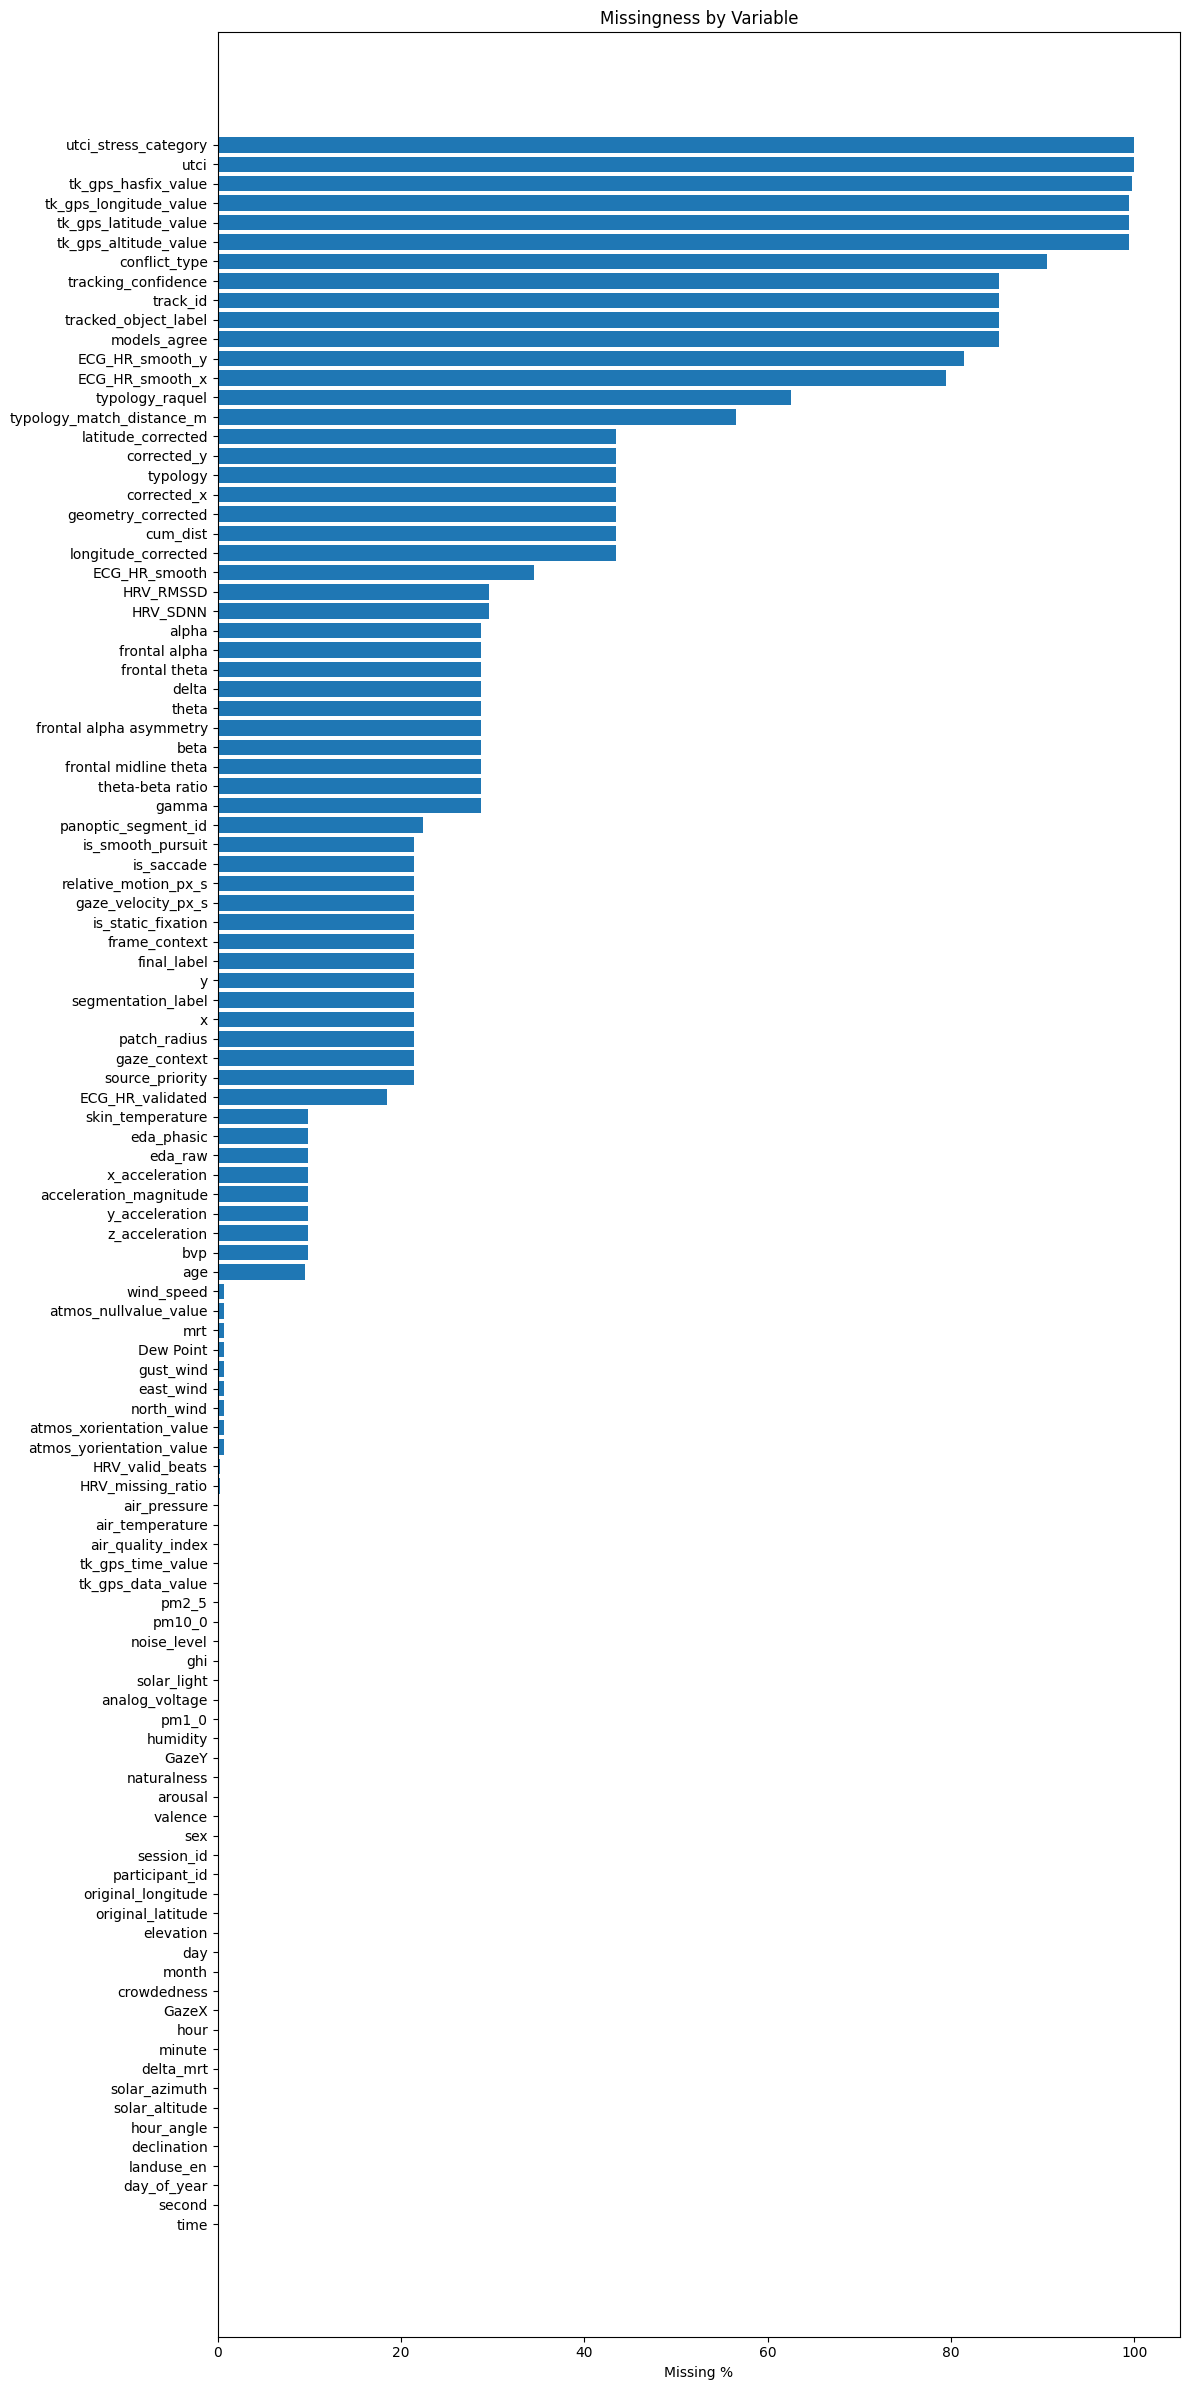


NUMERIC SUMMARY



,count,mean,std,min,25%,50%,75%,max
skin_temperature,21918.0,3.121259e+01,2.019816e+00,2.645000e+01,2.969000e+01,3.133500e+01,3.304000e+01,35.320000
eda_raw,21923.0,1.168508e+00,4.325208e+00,0.000000e+00,6.406630e-03,1.057164e-02,3.908057e-02,37.565785
eda_phasic,21923.0,-3.501641e-04,1.704390e-01,-4.644201e+00,-9.708288e-04,-9.439321e-05,7.051084e-04,3.084547
x_acceleration,21934.0,-1.508751e+01,1.698463e+01,-6.550000e+01,-2.462500e+01,-1.696875e+01,-7.843750e+00,62.687500
y_acceleration,21934.0,-3.624364e+01,4.680663e+01,-7.268750e+01,-6.303125e+01,-5.978125e+01,-5.125781e+01,79.062500
...,...,...,...,...,...,...,...,...
ECG_HR_smooth_y,4515.0,9.896694e+01,1.391067e+01,4.246309e+01,8.818215e+01,9.967161e+01,1.085860e+02,136.249630
tk_gps_latitude_value,135.0,-4.693801e+07,2.008299e+07,-5.570806e+07,-5.570764e+07,-5.570684e+07,-5.570667e+07,-644862.000000
tk_gps_longitude_value,135.0,-1.069241e+07,4.358870e+06,-1.259909e+07,-1.259882e+07,-1.259404e+07,-1.259232e+07,-644862.000000
tk_gps_altitude_value,136.0,1.116004e+03,5.966027e+02,0.000000e+00,8.032500e+02,9.220000e+02,1.626000e+03,2379.000000



LOW VARIANCE VARIABLES



,std
atmos_nullvalue_value,0.000000
patch_radius,0.000000
arousal,0.000000
month,0.000000
original_latitude,0.014768
longitude_corrected,0.015509
latitude_corrected,0.017346
original_longitude,0.021444
declination,0.062012
eda_phasic,0.170439



CATEGORY BALANCE


----------------------
typology
----------------------



...

session_id
Nordhavn     8590
Norrebro     6516
Hellerup     5183
Norreport    4034
Name: count, dtype: int64


----------------------
participant_id
----------------------



participant_id
OE022    3633
OE021    2859
OE023    2859
OE020    2602
OE009    2460
OE005    2313
OE024    1419
OE018    1139
OE015    1112
OE010    1034
OE002    1026
OE004     871
OE011     625
OE019     371
Name: count, dtype: int64


MODALITY COMPLETENESS MATRIX



,participant,session,rows,missing_total_%,ECG_%,HRV_%,EDA_%,EEG_%,EyeTracking_%,GPS_corrected_%,GPS_original_%,Typology_%,Landuse_%
0,sub-OE020,ses-Norrebro,1558,10.01,87.36,74.295,100.00,78.31,98.91,0.0,100.0,45.445,100.0
1,sub-OE020,ses-Nordhavn,1044,7.94,77.20,54.890,99.90,99.90,98.37,100.0,100.0,50.000,100.0
2,sub-OE005,ses-Nordhavn,1264,8.74,97.47,97.470,100.00,92.41,99.45,0.0,100.0,38.490,100.0
3,sub-OE005,ses-Hellerup,1049,9.12,83.13,54.430,100.00,97.81,98.86,100.0,100.0,50.000,100.0
4,sub-OE018,ses-Hellerup,1139,10.07,25.37,3.115,99.91,98.60,98.86,100.0,100.0,50.000,100.0
5,sub-OE021,ses-Norrebro,1261,9.61,74.39,44.925,100.00,86.92,98.81,0.0,100.0,43.020,100.0
6,sub-OE021,ses-Hellerup,1598,7.96,99.69,99.375,100.00,86.23,99.50,0.0,100.0,50.000,100.0
7,sub-OE015,ses-Norreport,1112,23.97,100.00,99.955,0.00,0.00,98.65,100.0,100.0,50.000,100.0
8,sub-OE002,ses-Hellerup,1026,9.52,33.63,0.830,99.90,99.12,99.81,100.0,100.0,50.000,100.0
9,sub-OE022,ses-Norrebro,1481,10.00,76.23,51.485,99.93,87.85,98.65,0.0,100.0,43.485,100.0


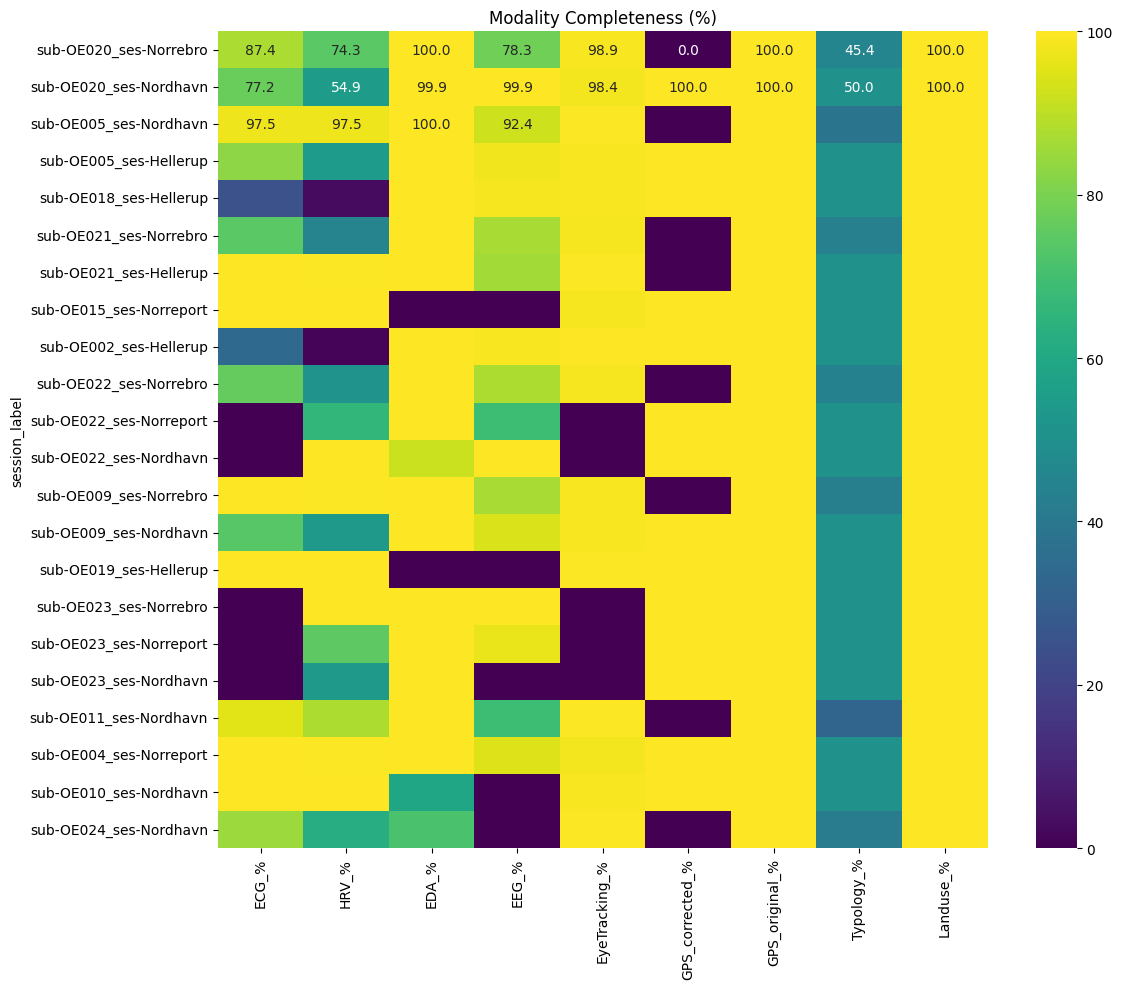


COLUMN CONSISTENCY



,session,n_missing_columns,missing_columns
0,sub-OE020_ses-Norrebro,13,"tk_gps_altitude_value, ECG_HR_smooth_y, correc..."
1,sub-OE020_ses-Nordhavn,8,"tk_gps_altitude_value, ECG_HR_smooth_y, tk_gps..."
2,sub-OE005_ses-Nordhavn,13,"tk_gps_altitude_value, ECG_HR_smooth_y, correc..."
3,sub-OE005_ses-Hellerup,8,"tk_gps_altitude_value, ECG_HR_smooth_y, tk_gps..."
4,sub-OE018_ses-Hellerup,8,"tk_gps_altitude_value, ECG_HR_smooth_y, tk_gps..."
5,sub-OE021_ses-Norrebro,13,"tk_gps_altitude_value, ECG_HR_smooth_y, correc..."
6,sub-OE021_ses-Hellerup,13,"tk_gps_altitude_value, ECG_HR_smooth_y, correc..."
7,sub-OE015_ses-Norreport,8,"tk_gps_altitude_value, ECG_HR_smooth_y, tk_gps..."
8,sub-OE002_ses-Hellerup,8,"tk_gps_altitude_value, ECG_HR_smooth_y, tk_gps..."
9,sub-OE022_ses-Norrebro,13,"tk_gps_altitude_value, ECG_HR_smooth_y, correc..."



DATA AUDIT COMPLETE

Sessions audited: 22
Total rows: 24,323
Total columns: 108


In [7]:
root = "/mnt/raid/emotional_data_raquel/fulldata_mine"

# =========================================================
# FIND ALL alldata_final FILES
# =========================================================

files = glob.glob(
    os.path.join(root, "**", "alldata_final.csv"),
    recursive=True
)

print(f"\nFound {len(files)} alldata_final.csv files\n")

# =========================================================
# SESSION-LEVEL AUDIT
# =========================================================

summary_rows = []

all_dfs = []

for file_path in files:

    print(f"Reading: {file_path}")

    try:

        df = pd.read_csv(file_path)

        # ---------------------------------------------
        # participant/session
        # ---------------------------------------------
        participant = file_path.split("/")[-3]
        session = file_path.split("/")[-2]

        # ---------------------------------------------
        # keep for global dataframe
        # ---------------------------------------------
        all_dfs.append(df)

        # ---------------------------------------------
        # modality completeness
        # ---------------------------------------------
        def completeness(col):

            if col not in df.columns:
                return 0

            return round(
                100 - (df[col].isna().mean() * 100),
                2
            )

        # ---------------------------------------------
        # session summary row
        # ---------------------------------------------
        row = {

            "participant": participant,
            "session": session,

            "rows": len(df),
            "columns": len(df.columns),

            "duplicates":
                int(df.duplicated().sum()),

            "missing_total_%":
                round(
                    df.isna().mean().mean() * 100,
                    2
                ),

            # -----------------------------------------
            # modalities
            # -----------------------------------------
            "ECG_%":
                completeness("ECG_HR_smooth"),

            "HRV_%":
            np.nanmean([
                completeness("HRV_RMSSD"),
                completeness("HRV_SDNN")
            ]),

            "EDA_%":
                completeness("eda_phasic"),

            "EEG_%":
                completeness("alpha"),

            "EyeTracking_%":
                completeness("final_label"),

            "GPS_corrected_%":
                completeness("longitude_corrected"),

            "GPS_original_%":
                completeness("original_longitude"),

            "Typology_%":
                np.nanmean([
                    completeness("typology"),
                    completeness("typology_raquel")
                ]),

            "Landuse_%":
                completeness("landuse_en"),

            # -----------------------------------------
            # column existence
            # -----------------------------------------
            "has_ECG":
                "ECG_HR_smooth" in df.columns,

            "has_HRV":
                (
                    "HRV_RMSSD" in df.columns
                    and
                    "HRV_SDNN" in df.columns
                ),

            "has_EEG":
                "alpha" in df.columns,

            "has_eye_tracking":
                "final_label" in df.columns,

            "has_typology":
                (
                    "typology" in df.columns
                    or
                    "typology_raquel" in df.columns
                ),

            "has_landuse":
                "landuse_en" in df.columns,

            "has_corrected_gps":
                (
                    "longitude_corrected" in df.columns
                    and
                    "latitude_corrected" in df.columns
                ),

            "has_original_gps":
                (
                    "original_longitude" in df.columns
                    and
                    "original_latitude" in df.columns
                ),
        }

        # ---------------------------------------------
        # session duration
        # ---------------------------------------------
        if "time" in df.columns:

            try:

                df["time"] = pd.to_datetime(df["time"])

                duration = (
                    df["time"].max()
                    -
                    df["time"].min()
                )

                row["duration_minutes"] = round(
                    duration.total_seconds() / 60,
                    2
                )

            except:

                row["duration_minutes"] = np.nan

        else:

            row["duration_minutes"] = np.nan

        summary_rows.append(row)

    except Exception as e:

        print(f"\nFAILED: {file_path}")
        print(e)

# =========================================================
# CREATE SUMMARY DATAFRAME
# =========================================================

summary_df = pd.DataFrame(summary_rows)

print("\n==============================")
print("SESSION SUMMARY")
print("==============================\n")

display(summary_df)

# =========================================================
# SAVE SESSION SUMMARY
# =========================================================

# summary_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "session_data_audit_summary.csv"
# )

# summary_df.to_csv(summary_output, index=False)

# print(f"\nSaved session summary:")
# print(summary_output)

# =========================================================
# CONCATENATE ALL DATA
# =========================================================

df_all = pd.concat(
    all_dfs,
    ignore_index=True
)

print("\n==============================")
print("GLOBAL DATASET")
print("==============================\n")

print(df_all.shape)

# =========================================================
# GLOBAL MISSINGNESS
# =========================================================

missing = (
    df_all
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_df = pd.DataFrame({
    "missing_%": missing
})

print("\n==============================")
print("MISSINGNESS")
print("==============================\n")

display(missing_df)

# =========================================================
# SAVE MISSINGNESS
# =========================================================

# missing_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "global_missingness_summary.csv"
# )

# missing_df.to_csv(missing_output)

# =========================================================
# MISSINGNESS PLOT
# =========================================================

missing_df_sorted = missing_df.sort_values(
    "missing_%"
)

plt.figure(figsize=(12, 24))

plt.barh(
    missing_df_sorted.index,
    missing_df_sorted["missing_%"]
)

plt.xlabel("Missing %")
plt.title("Missingness by Variable")

plt.tight_layout()

plt.show()

# =========================================================
# NUMERIC SUMMARY
# =========================================================

numeric_df = df_all.select_dtypes(include=np.number)

summary_stats = numeric_df.describe().T

print("\n==============================")
print("NUMERIC SUMMARY")
print("==============================\n")

display(summary_stats)

# =========================================================
# SAVE NUMERIC SUMMARY
# =========================================================

# numeric_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "numeric_summary_statistics.csv"
# )

# summary_stats.to_csv(numeric_output)

# =========================================================
# LOW VARIANCE VARIABLES
# =========================================================

stds = numeric_df.std().sort_values()

low_variance_df = pd.DataFrame({
    "std": stds
})

print("\n==============================")
print("LOW VARIANCE VARIABLES")
print("==============================\n")

display(low_variance_df.head(30))

# =========================================================
# CATEGORY BALANCE
# =========================================================

categorical_vars = [
    "typology",
    "landuse_en",
    "final_label",
    "session_id",
    "participant_id"
]

print("\n==============================")
print("CATEGORY BALANCE")
print("==============================\n")

for var in categorical_vars:

    if var in df_all.columns:

        print(f"\n----------------------")
        print(var)
        print("----------------------\n")

        display(
            df_all[var]
            .value_counts(dropna=False)
            .head(50)
        )

# =========================================================
# SESSION-LEVEL MODALITY MATRIX
# =========================================================

print("\n==============================")
print("MODALITY COMPLETENESS MATRIX")
print("==============================\n")

modality_df = summary_df[
    [
        "participant",
        "session",
        "rows",
        "missing_total_%",
        "ECG_%",
        "HRV_%",
        "EDA_%",
        "EEG_%",
        "EyeTracking_%",
        "GPS_corrected_%",
        "GPS_original_%",
        "Typology_%",
        "Landuse_%"
    ]
].copy()

display(modality_df)

# =========================================================
# SAVE MODALITY MATRIX
# =========================================================

# modality_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "modality_completeness_matrix.csv"
# )

# modality_df.to_csv(modality_output, index=False)

# =========================================================
# MODALITY HEATMAP
# =========================================================

heatmap_df = modality_df.copy()

heatmap_df["session_label"] = (
    heatmap_df["participant"]
    +
    "_"
    +
    heatmap_df["session"]
)

heatmap_df = heatmap_df.set_index(
    "session_label"
)

heatmap_data = heatmap_df[
    [
        "ECG_%",
        "HRV_%",
        "EDA_%",
        "EEG_%",
        "EyeTracking_%",
        "GPS_corrected_%",
        "GPS_original_%",
        "Typology_%",
        "Landuse_%"
    ]
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis",
    fmt=".1f"
)

plt.title("Modality Completeness (%)")

plt.tight_layout()

plt.show()

# =========================================================
# COLUMN CONSISTENCY CHECK
# =========================================================

print("\n==============================")
print("COLUMN CONSISTENCY")
print("==============================\n")

column_sets = {}

for file_path in files:

    df = pd.read_csv(file_path)

    participant = file_path.split("/")[-3]
    session = file_path.split("/")[-2]

    key = f"{participant}_{session}"

    column_sets[key] = set(df.columns)

all_columns = set.union(*column_sets.values())

column_summary = []

for key, cols in column_sets.items():

    missing_cols = list(all_columns - cols)

    column_summary.append({

        "session": key,
        "n_missing_columns": len(missing_cols),
        "missing_columns": ", ".join(missing_cols)
    })

column_summary_df = pd.DataFrame(column_summary)

display(column_summary_df)

# =========================================================
# SAVE COLUMN CONSISTENCY
# =========================================================

# column_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "column_consistency_summary.csv"
# )

# column_summary_df.to_csv(column_output, index=False)

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n===================================")
print("DATA AUDIT COMPLETE")
print("===================================\n")

print(f"Sessions audited: {len(summary_df)}")
print(f"Total rows: {len(df_all):,}")
print(f"Total columns: {len(df_all.columns)}")

# print("\nSaved outputs:")

# print(summary_output)
# print(missing_output)
# print(numeric_output)
# print(modality_output)
# print(column_output)

# Exploratory Data Audit Summary

A total of 14 `alldata_final.csv` sessions were audited, resulting in:
- 20,184 observations
- 91 variables
- 0 duplicated rows

Session durations were mostly stable (~22–28 min), except `sub-OE019_ses-Hellerup` (~14 min).

---

# Modality Coverage Summary

### ECG insights

ECG coverage was generally good across sessions, ranging from ~32% to 100%.

Best ECG sessions:
- `OE015`
- `OE019`
- `OE004`
- `OE023_Norrebro`

Lowest ECG coverage:
- `OE002`
- `OE018`

ECG distributions looked physiologically plausible for ambulatory outdoor recordings.

---

### EDA insights

EDA was highly complete in most sessions (~100%).

Completely missing in:
- `OE015`
- `OE019`

Partial availability:
- `OE010`
- `OE022_Nordhavn`

`eda_phasic` was strongly centered around zero with sparse high peaks, which is expected in ecological recordings.

EDA differences across typologies were subtle.

---

### EEG insights

EEG coverage was mostly strong (~67–88%).

No EEG available in:
- `OE015`
- `OE019`
- `OE010`
- `OE023_Nordhavn`

EEG distributions were strongly right-skewed, which is expected for raw spectral power values.

---

### Eye-tracking insights

Eye tracking was only available for:
- `OE002`
- `OE004`
- `OE005`
- `OE009`
- `OE010`

Coverage within these sessions was excellent (~98–99%).

Globally, eye-tracking variables (`final_label`, `track_id`, `conflict_type`, etc.) appeared highly missing because most sessions never had eye-tracking fusion performed.

Most common gaze targets:
- building
- road
- vegetation
- person
- car

---

### GPS insights

Corrected GPS and original GPS coordinates had essentially complete coverage across all sessions.

Key GPS variables:
- `latitude_corrected`
- `longitude_corrected`
- `cum_dist`

All appeared structurally coherent after cleaning.

---

### Typology insights

Typology coverage was generally very high (>90%).

Lowest typology completeness:
- `OE023_Norrebro` (~69%)

Typology distribution:
- `U+N` → most common
- `U+M` → second most common
- `N` → least common

Movement (`acceleration_magnitude`) varied only slightly between typologies.

---

### Landuse insights

Landuse coverage reached 100% across all sessions.

Most common landuse categories:
- Mixed Residential and Commercial
- Technical Infrastructure
- Residential Area

Least represented:
- Public Service Area

---

### Climate insights

Climate/environmental variables showed extremely low missingness (<1%).

Variables included:
- air_temperature
- humidity
- mrt
- wind_speed
- pm1_0
- pm2_5
- pm10_0
- noise_level

Strong environmental relationships observed:
- air_temperature ↔ humidity → strong negative correlation
- air_temperature ↔ mrt → moderate positive correlation

---

# Missingness Insights

Largest missing blocks were modality-dependent rather than random.

Main issues:
- `utci` and `utci_stress_category` → 100% missing
- `tk_gps_*` variables → almost completely missing
- eye-tracking variables missing in non-fused sessions

Variables with essentially no missing data:
- GPS corrected coordinates
- gaze coordinates
- typology
- landuse
- timestamps

---

# Column Consistency Insights

Sessions without eye tracking were missing ~14 eye-tracking-related columns.

Sessions with fused eye tracking contained:
- 87–91 columns

Most complete session:
- `OE010_ses-Nordhavn`

Dataset structure now appears coherent and analysis-ready.

In [5]:
for col in [
    "valence",
    "arousal",
    "naturalness",
    "crowdedness"
]:
    print("\n", col)
    print(df_all[col].value_counts(dropna=False))


 valence
valence
0    18742
1     1442
Name: count, dtype: int64

 arousal
arousal
0    20184
Name: count, dtype: int64

 naturalness
naturalness
 5                      7783
 6                      4159
 4                      3726
-9223372036854775808    2925
 7                      1591
Name: count, dtype: int64

 crowdedness
crowdedness
 7                      4702
 4                      3752
 3                      3050
-9223372036854775808    2925
 5                      2897
 8                      1432
 2                      1426
Name: count, dtype: int64


_________

In [13]:
# # Renaming original coordinates files from "typology_raquel" to just "typology" as the rest has it
# root = "/mnt/raid/emotional_data_raquel/fulldata_mine"

# files = glob(os.path.join(root, "**", "alldata_final.csv"),recursive=True
# )

# print(f"\nFound {len(files)} files\n")

# for file_path in files:

#     print(f"Processing: {file_path}")

#     try:

#         backup_path = file_path.replace(
#             "alldata_final.csv",
#             "alldata_final_old.csv"
#         )

#         if not os.path.exists(backup_path):
#             shutil.copy2(file_path, backup_path)

#         df = pd.read_csv(file_path)

#         if "typology_raquel" in df.columns:

#             if "typology" in df.columns:
#                 df = df.drop(columns=["typology"])

#             df = df.rename(columns={
#                 "typology_raquel": "typology"
#             })

#             df.to_csv(file_path, index=False)

#             print("  Renamed typology_raquel → typology")

#         else:
#             print("  No typology_raquel column")

#     except Exception as e:

#         print(f"  ERROR: {e}")

# print("\n✓ DONE")


Found 22 files

Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE020/ses-Norrebro/alldata_final.csv
  Renamed typology_raquel → typology
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE020/ses-Nordhavn/alldata_final.csv
  No typology_raquel column
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE005/ses-Nordhavn/alldata_final.csv
  Renamed typology_raquel → typology
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE005/ses-Hellerup/alldata_final.csv
  No typology_raquel column
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE018/ses-Hellerup/alldata_final.csv
  No typology_raquel column
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE021/ses-Norrebro/alldata_final.csv
  Renamed typology_raquel → typology
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE021/ses-Hellerup/alldata_final.csv
  Renamed typology_raquel → typology
Processing: /mnt/raid/emotional_data_raquel/fulldata_mine/

__________

# Exploratory Analysis

Loading → sub-OE002 | ses-Hellerup
Loading → sub-OE004 | ses-Norreport
Loading → sub-OE005 | ses-Hellerup
Loading → sub-OE005 | ses-Nordhavn
Loading → sub-OE009 | ses-Nordhavn
Loading → sub-OE009 | ses-Norrebro
Loading → sub-OE010 | ses-Nordhavn
Loading → sub-OE011 | ses-Nordhavn
Loading → sub-OE015 | ses-Norreport
Loading → sub-OE018 | ses-Hellerup
Loading → sub-OE019 | ses-Hellerup
Loading → sub-OE020 | ses-Nordhavn
Loading → sub-OE020 | ses-Norrebro
Loading → sub-OE021 | ses-Hellerup
Loading → sub-OE021 | ses-Norrebro
Loading → sub-OE022 | ses-Nordhavn
Loading → sub-OE022 | ses-Norrebro
Loading → sub-OE022 | ses-Norreport
Loading → sub-OE023 | ses-Nordhavn
Loading → sub-OE023 | ses-Norrebro
Loading → sub-OE023 | ses-Norreport
Loading → sub-OE024 | ses-Nordhavn


GLOBAL DATASET
(24323, 109)


PARTICIPANTS
participant
sub-OE022    3633
sub-OE021    2859
sub-OE023    2859
sub-OE020    2602
sub-OE009    2460
sub-OE005    2313
sub-OE024    1419
sub-OE018    1139
sub-OE015    1112
sub-OE0

,count,mean,std,min,25%,50%,75%,max
skin_temperature,21918.0,3.121259e+01,2.019816e+00,2.645000e+01,2.969000e+01,3.133500e+01,3.304000e+01,35.320000
eda_raw,21923.0,1.168508e+00,4.325208e+00,0.000000e+00,6.406630e-03,1.057164e-02,3.908057e-02,37.565785
eda_phasic,21923.0,-3.501641e-04,1.704390e-01,-4.644201e+00,-9.708288e-04,-9.439321e-05,7.051084e-04,3.084547
x_acceleration,21934.0,-1.508751e+01,1.698463e+01,-6.550000e+01,-2.462500e+01,-1.696875e+01,-7.843750e+00,62.687500
y_acceleration,21934.0,-3.624364e+01,4.680663e+01,-7.268750e+01,-6.303125e+01,-5.978125e+01,-5.125781e+01,79.062500
...,...,...,...,...,...,...,...,...
tk_gps_longitude_value,135.0,-1.069241e+07,4.358870e+06,-1.259909e+07,-1.259882e+07,-1.259404e+07,-1.259232e+07,-644862.000000
tk_gps_altitude_value,136.0,1.116004e+03,5.966027e+02,0.000000e+00,8.032500e+02,9.220000e+02,1.626000e+03,2379.000000
tk_gps_hasfix_value,55.0,6.363636e-01,4.854794e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000
ECG_HR_smooth_x,4999.0,9.983377e+01,1.290174e+01,6.414864e+01,8.984817e+01,1.000747e+02,1.087422e+02,134.776219




MISSINGNESS


,missing_%
utci_stress_category,100.000000
utci,100.000000
tk_gps_hasfix_value,99.773877
tk_gps_latitude_value,99.444970
tk_gps_longitude_value,99.444970
...,...
sex,0.000000
valence,0.000000
arousal,0.000000
naturalness,0.000000


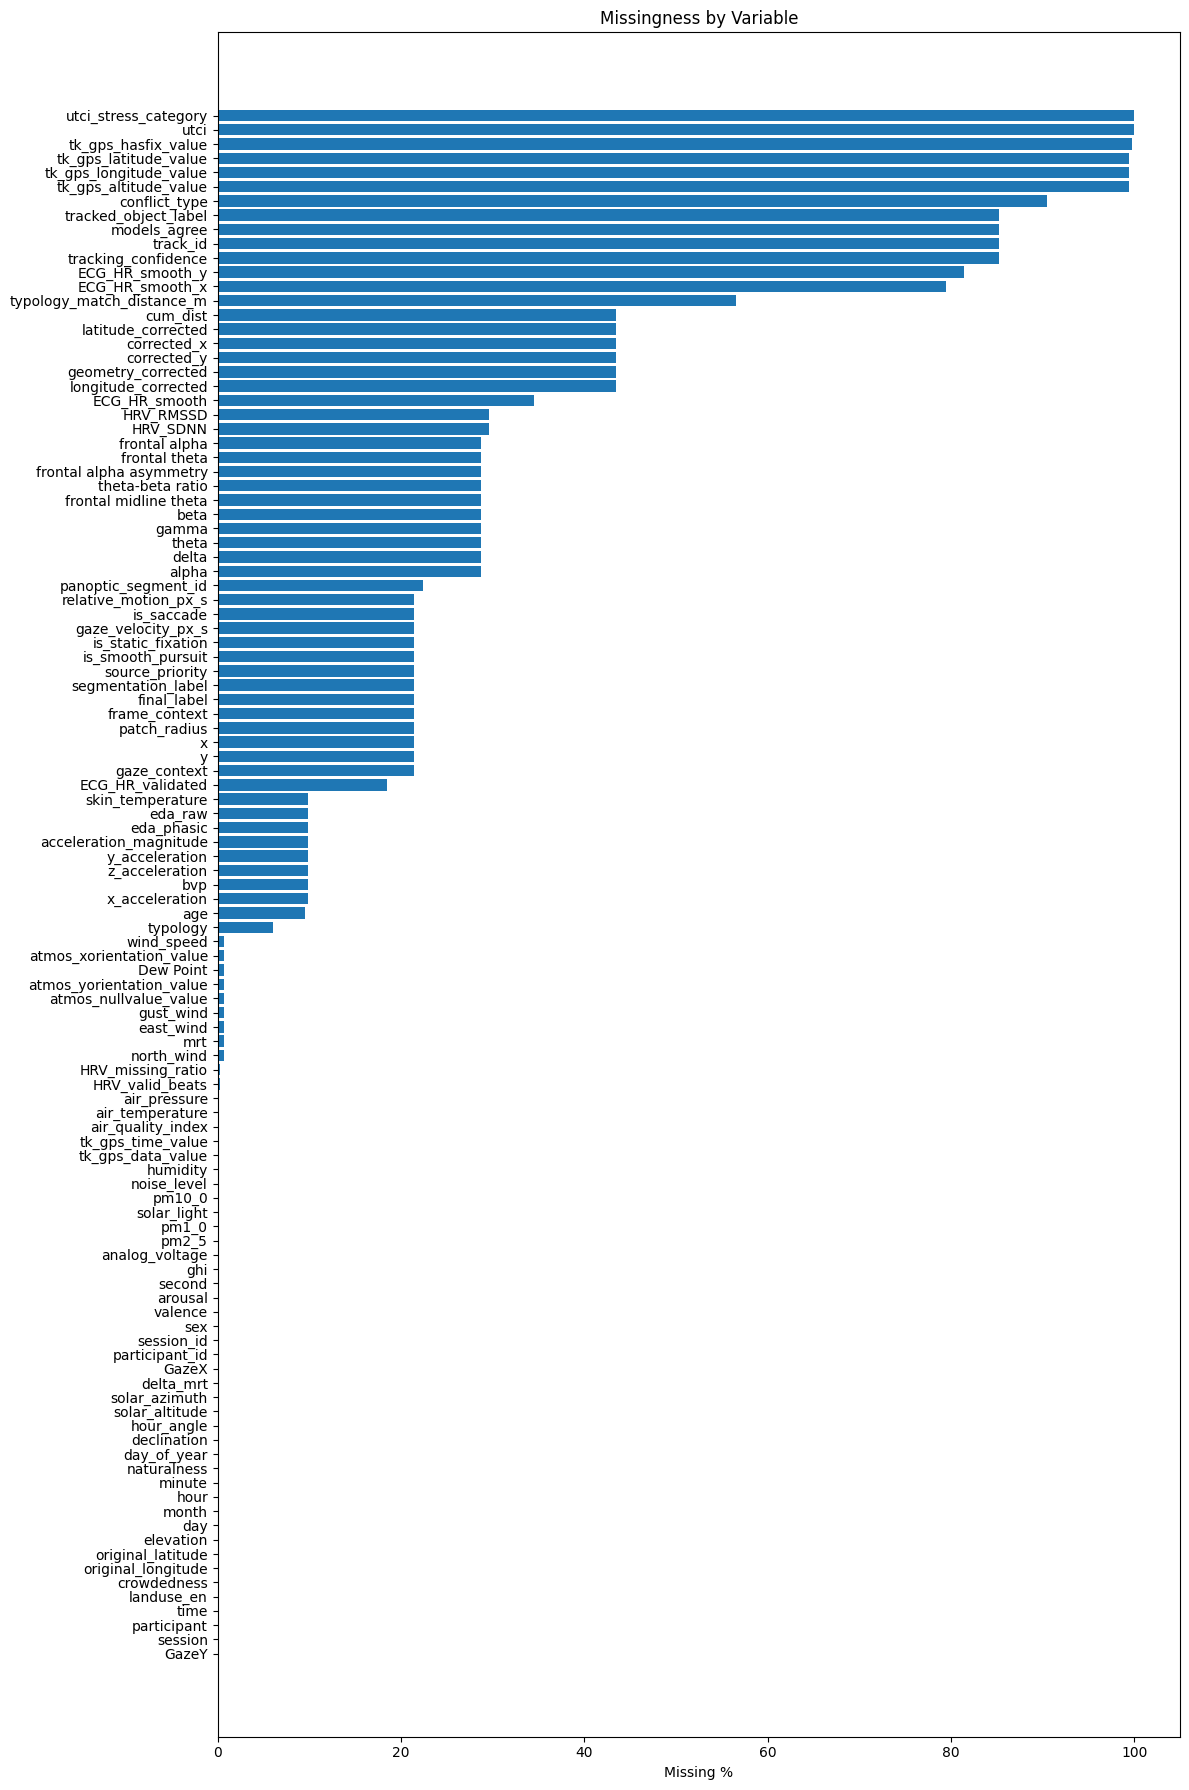



PARTICIPANT_ID COUNTS
participant_id
OE022    3633
OE021    2859
OE023    2859
OE020    2602
OE009    2460
OE005    2313
OE024    1419
OE018    1139
OE015    1112
OE010    1034
OE002    1026
OE004     871
OE011     625
OE019     371
Name: count, dtype: int64


SESSION_ID COUNTS
session_id
Nordhavn     8590
Norrebro     6516
Hellerup     5183
Norreport    4034
Name: count, dtype: int64


TYPOLOGY COUNTS
typology
U+M      6901
U+N      6068
U        3967
U+N+M    3363
N        2558
NaN      1466
Name: count, dtype: int64


LANDUSE_EN COUNTS
landuse_en
Technical Infrastructure            7123
Mixed Residential and Commercial    6393
Recreational Area                   3531
Residential Area                    3397
Commercial / Industrial Area        2788
Urban Center                        1024
Public Service Area                   57
Other                                 10
Name: count, dtype: int64


FINAL_LABEL COUNTS
final_label
NaN              5204
building         4800
road       

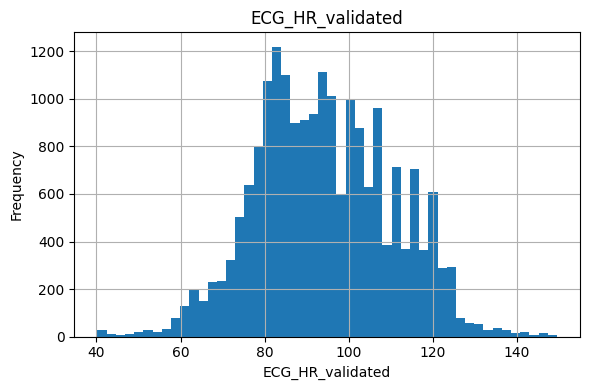

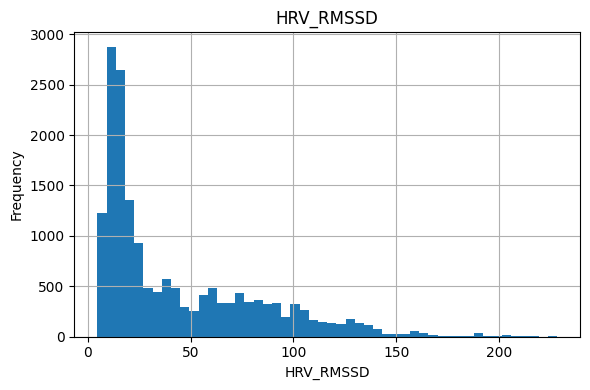

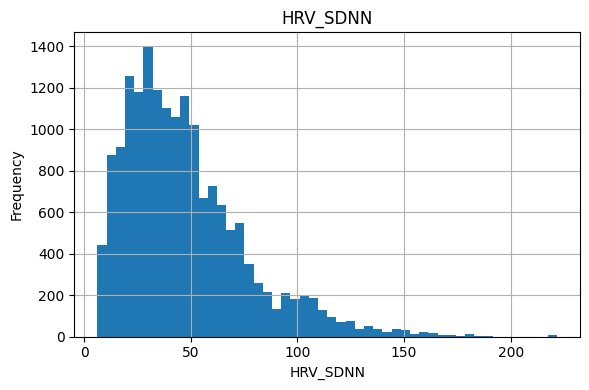

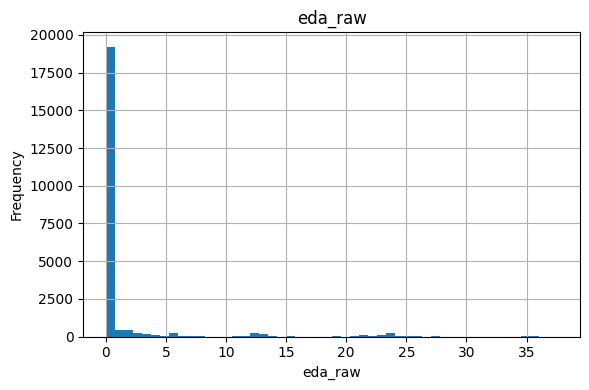

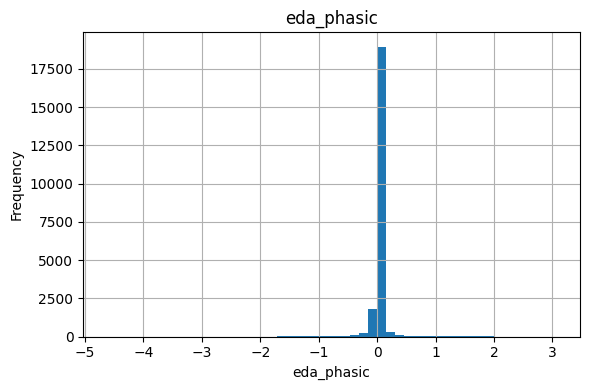

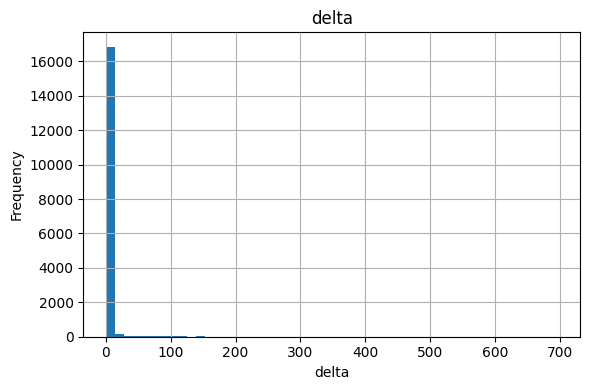

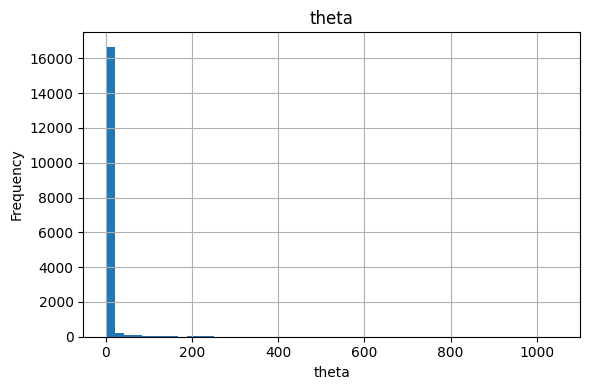

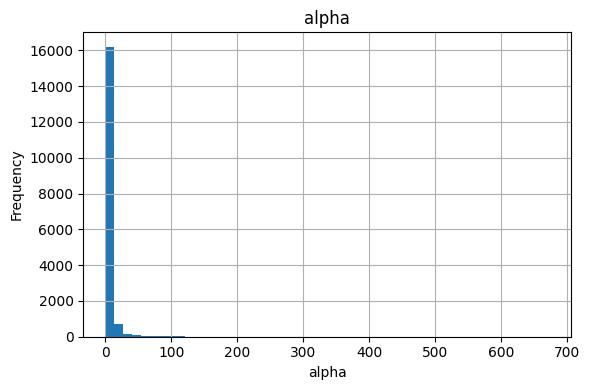

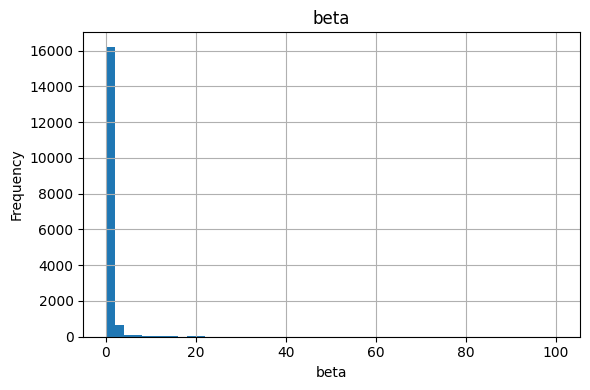

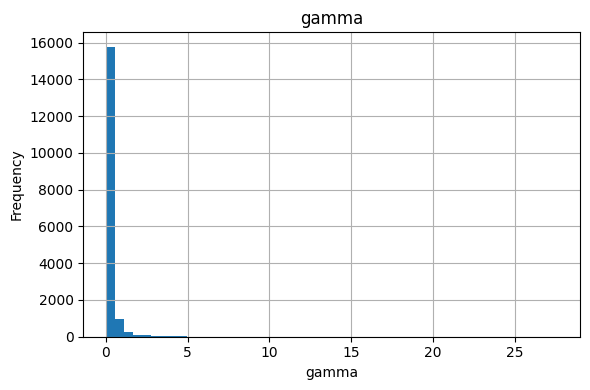

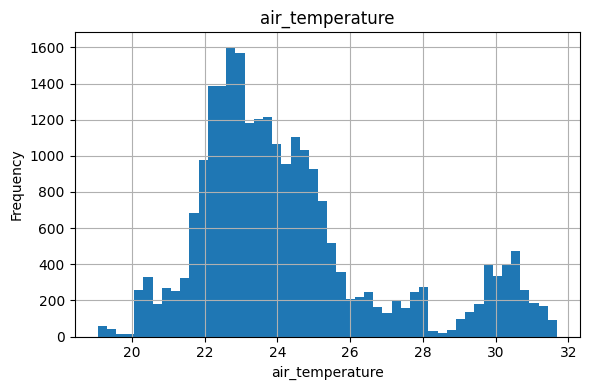

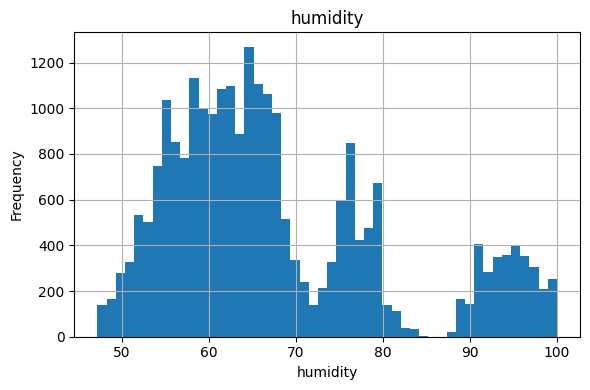

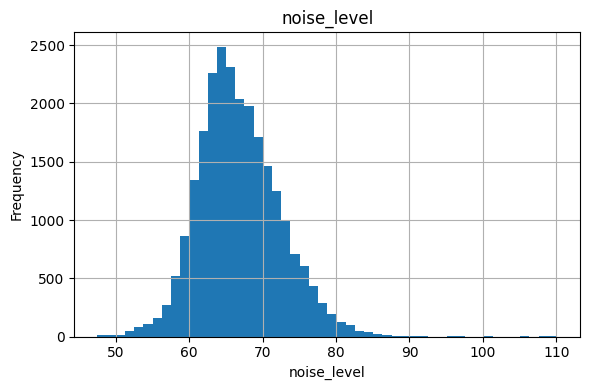

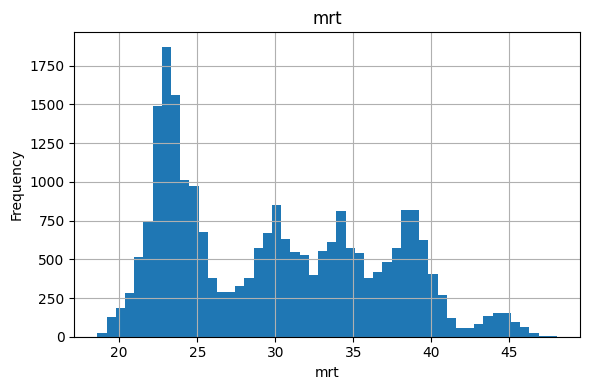

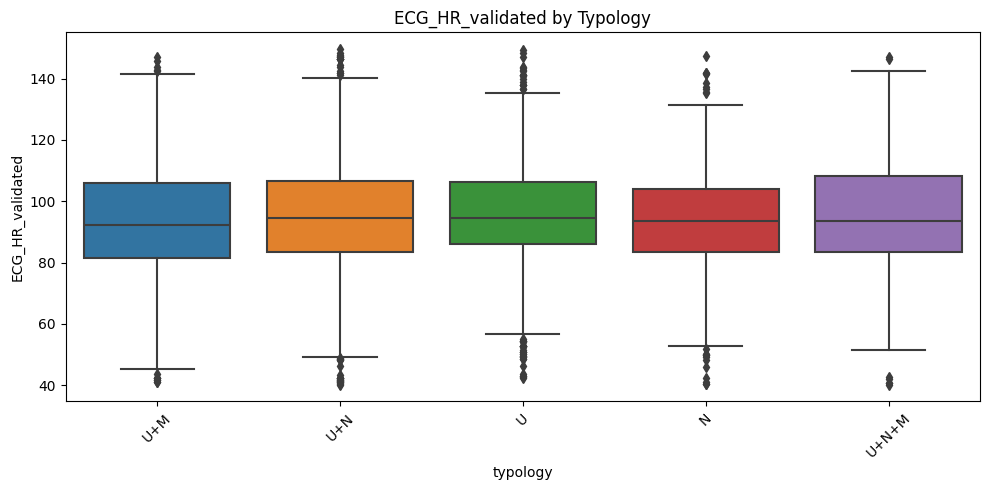

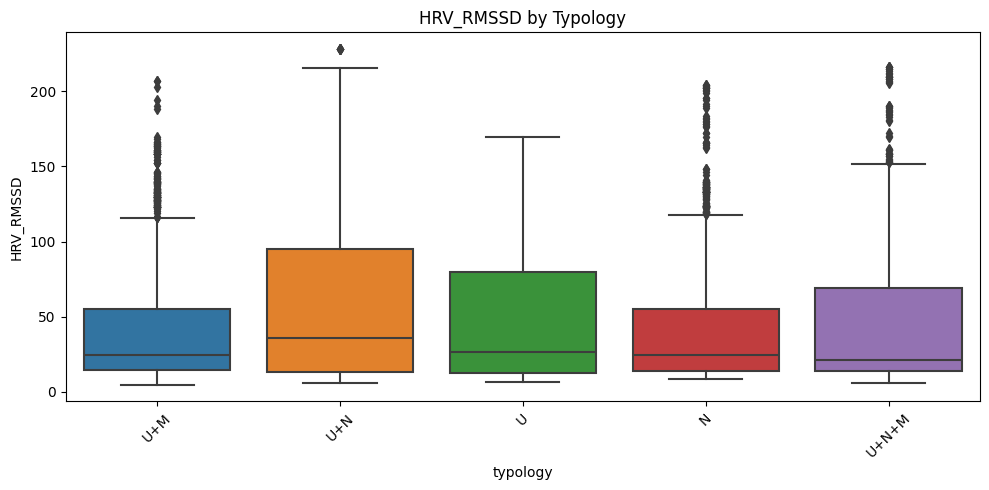

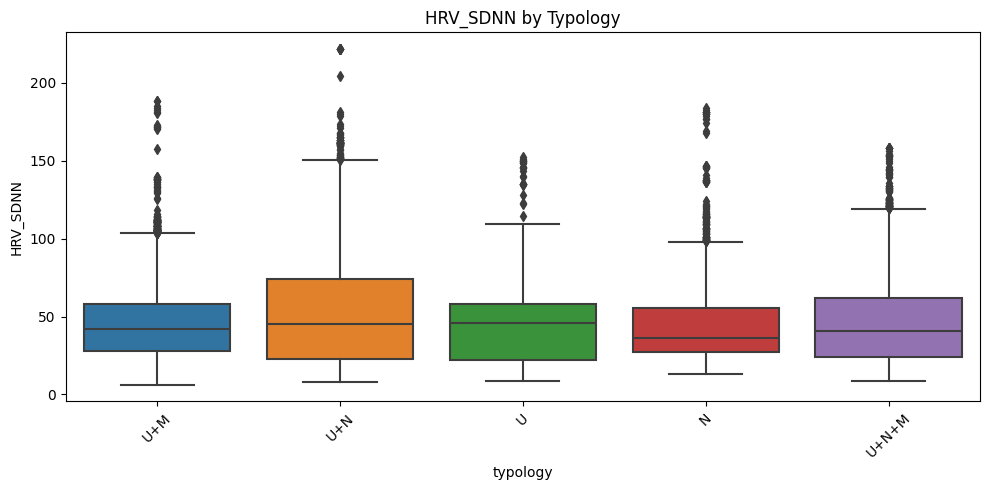

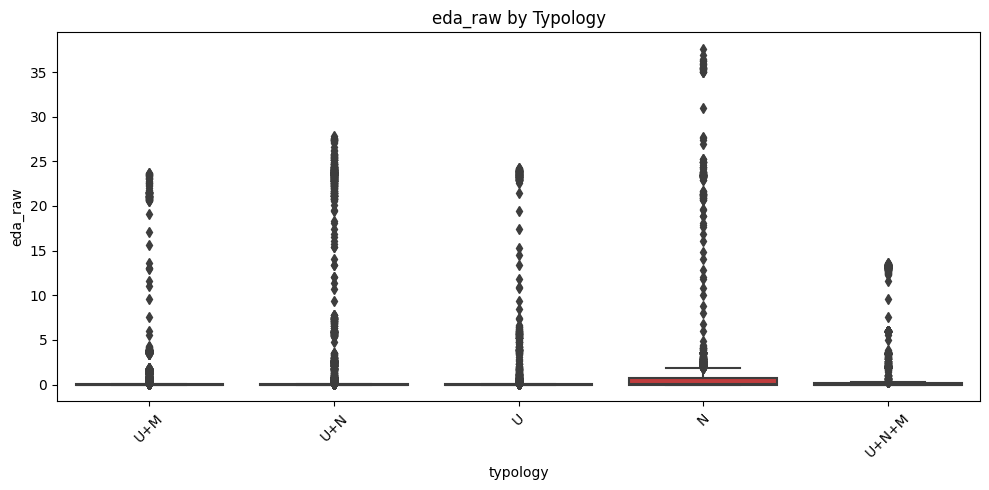

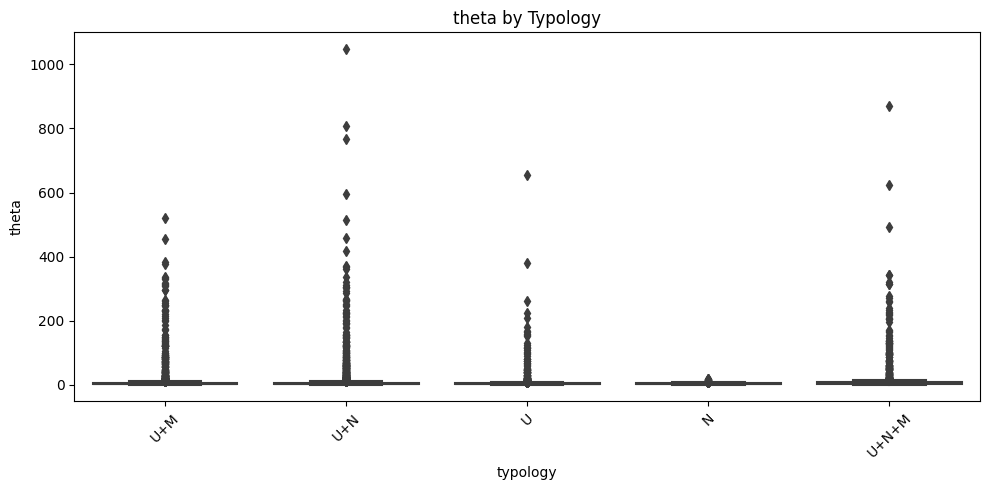

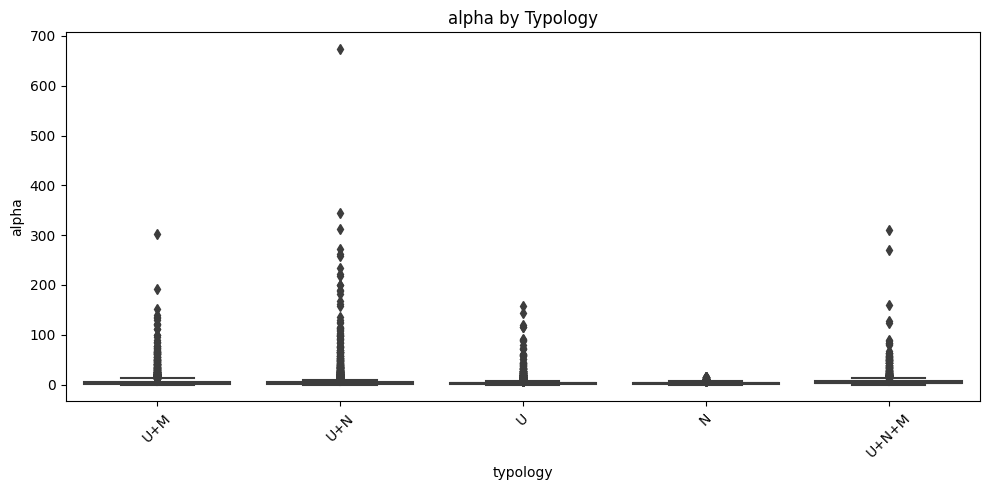

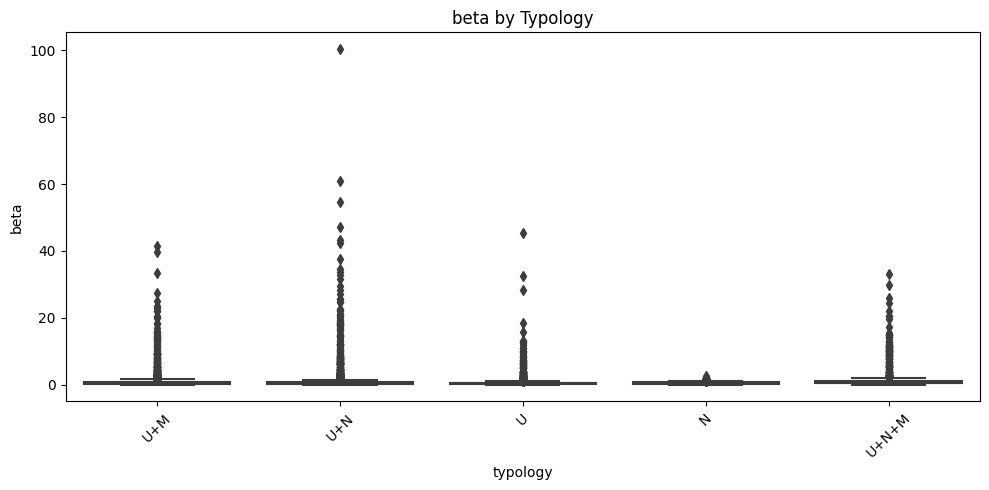

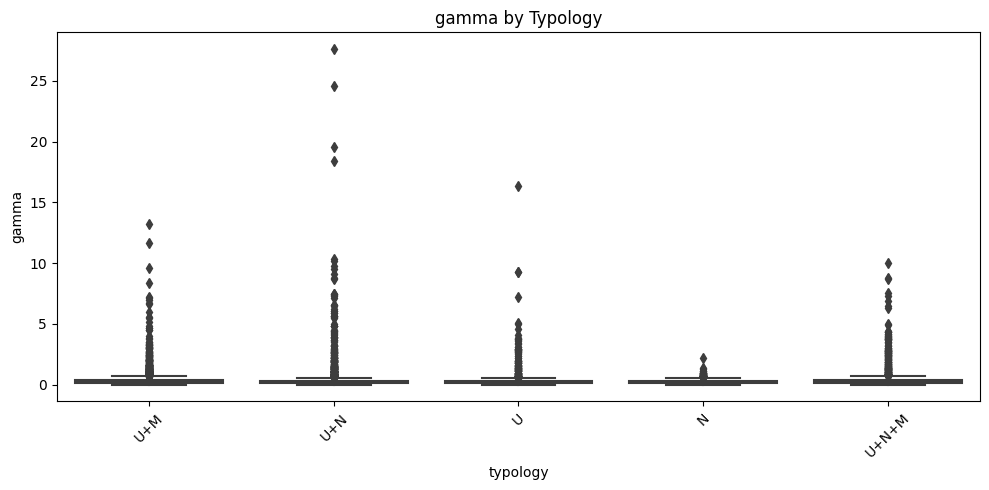

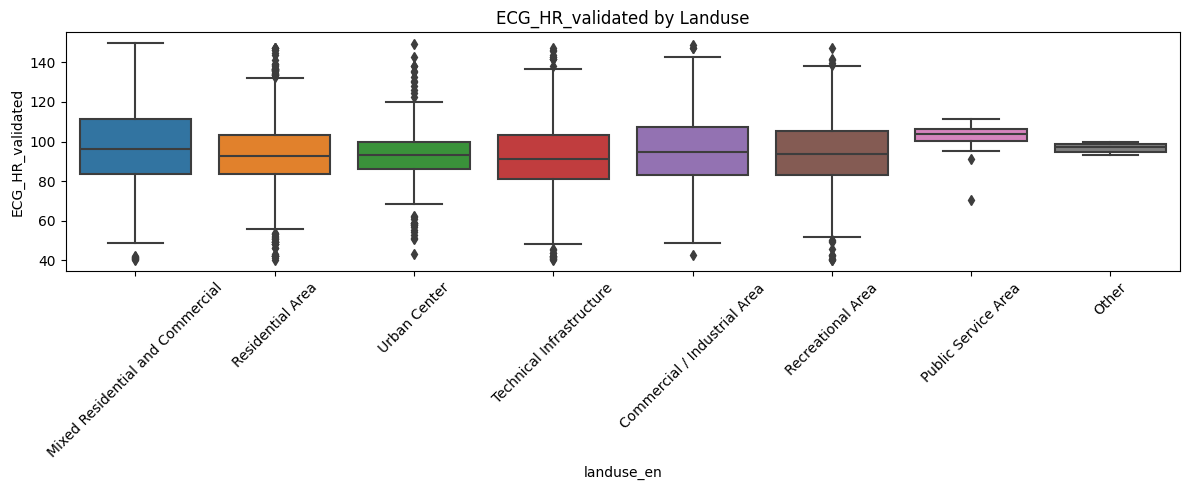

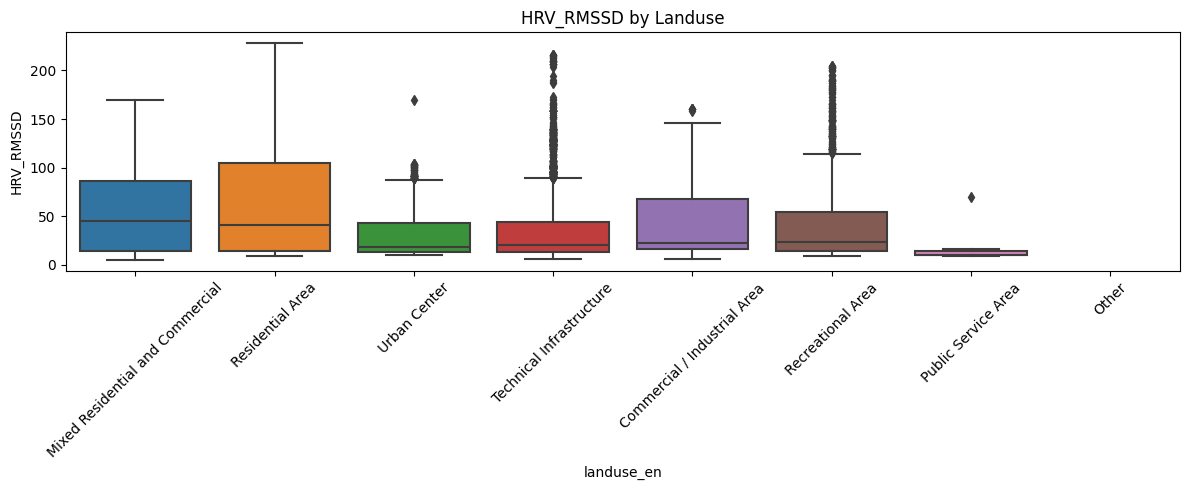

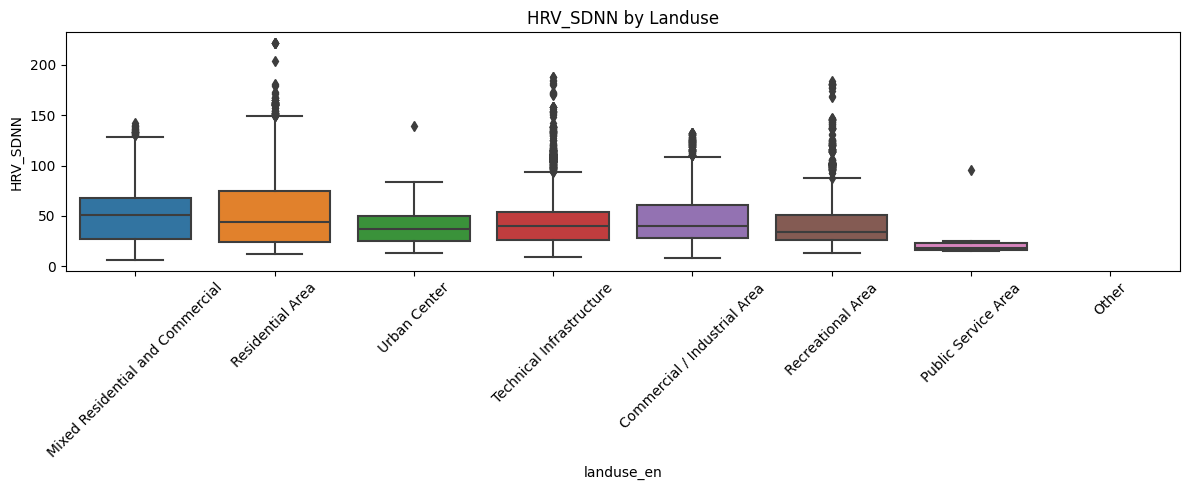

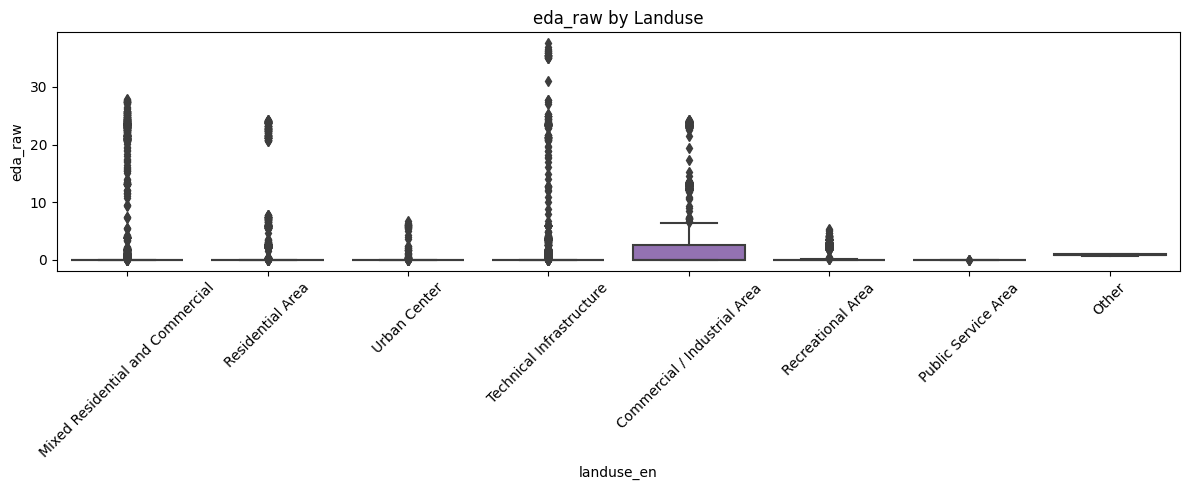

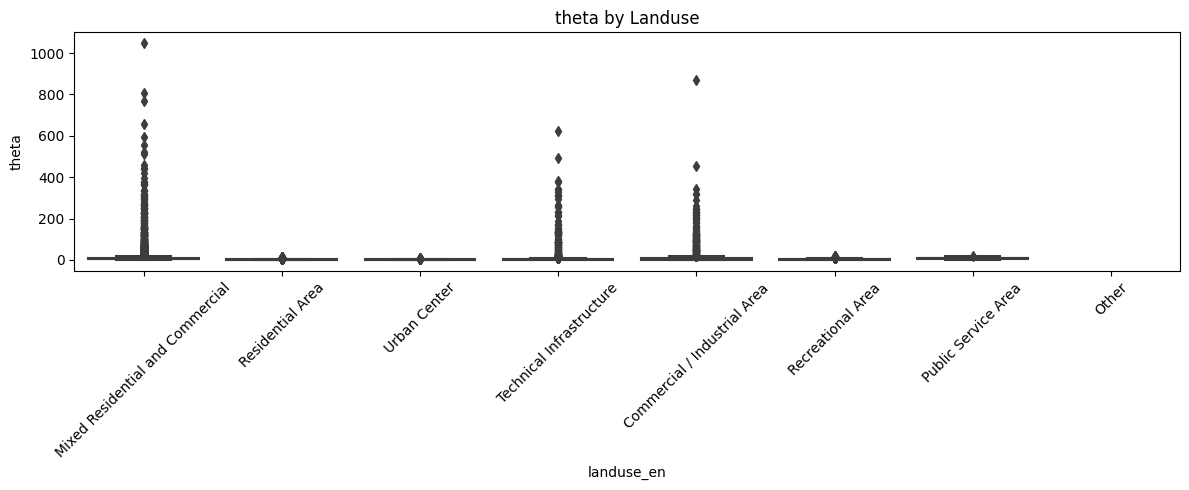

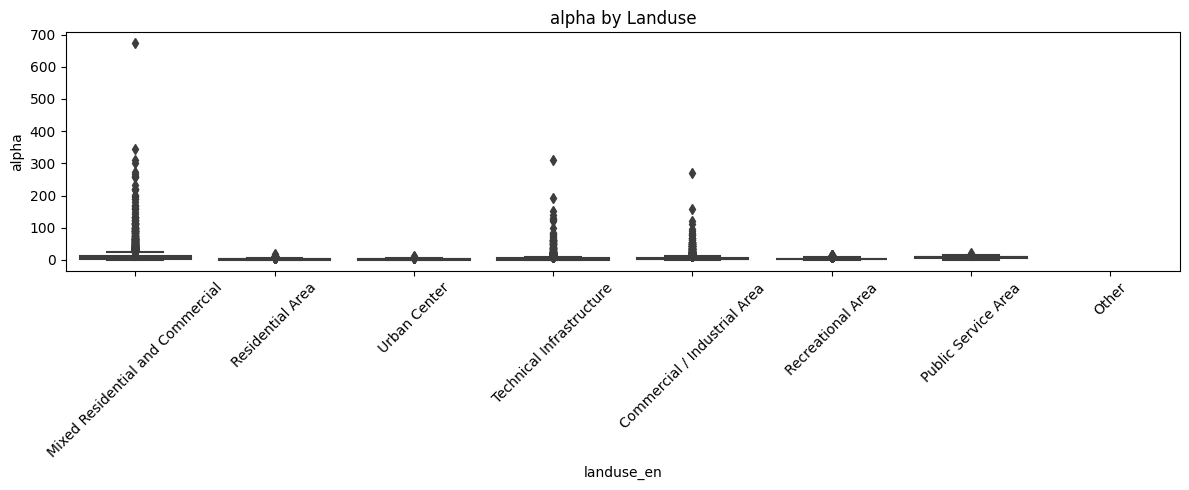

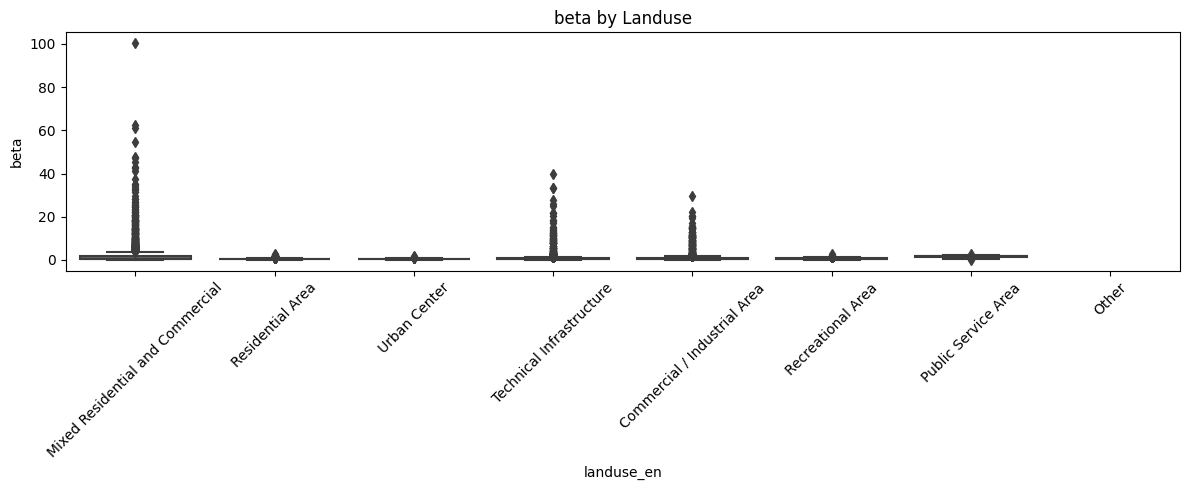

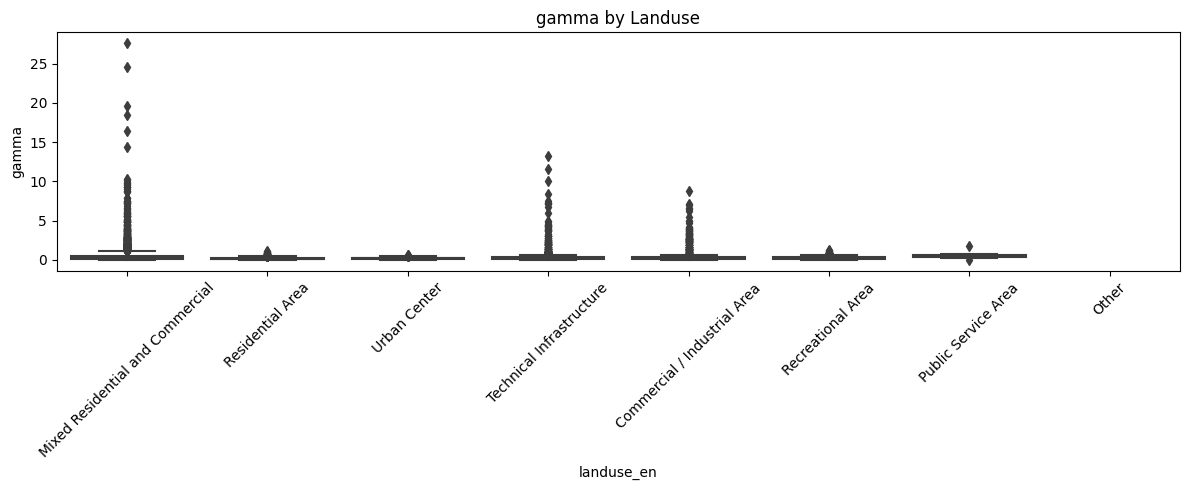



CORRELATION MATRIX


,ECG_HR_validated,HRV_RMSSD,HRV_SDNN,eda_raw,eda_phasic,delta,theta,alpha,beta,gamma,air_temperature,humidity,noise_level,mrt
ECG_HR_validated,1.000000,-0.157316,-0.235352,0.082328,0.013585,-0.048332,0.067003,0.154574,0.117308,0.088590,0.275990,-0.147586,0.067411,0.054590
HRV_RMSSD,-0.157316,1.000000,0.830968,0.257610,0.005031,0.192422,0.156135,0.109323,0.138281,0.147276,0.131007,-0.044870,0.015829,0.041957
HRV_SDNN,-0.235352,0.830968,1.000000,0.204154,0.005275,0.194654,0.121491,0.043969,0.090983,0.095464,0.107421,0.005314,0.015146,0.076741
eda_raw,0.082328,0.257610,0.204154,1.000000,0.043614,0.132120,0.165627,0.170540,0.182613,0.199176,0.145357,0.073707,0.012991,0.038198
eda_phasic,0.013585,0.005031,0.005275,0.043614,1.000000,-0.005159,0.012308,0.013632,0.006337,0.001186,0.001833,-0.002524,0.001566,0.002505
delta,-0.048332,0.192422,0.194654,0.132120,-0.005159,1.000000,0.588644,0.418802,0.496480,0.441556,-0.074618,0.234396,0.034344,-0.105567
theta,0.067003,0.156135,0.121491,0.165627,0.012308,0.588644,1.000000,0.808863,0.783524,0.676231,-0.082997,0.245899,0.033316,-0.117506
alpha,0.154574,0.109323,0.043969,0.170540,0.013632,0.418802,0.808863,1.000000,0.855556,0.704486,-0.069119,0.195577,0.038925,-0.112088
beta,0.117308,0.138281,0.090983,0.182613,0.006337,0.496480,0.783524,0.855556,1.000000,0.859456,-0.076680,0.226864,0.042210,-0.114511
gamma,0.088590,0.147276,0.095464,0.199176,0.001186,0.441556,0.676231,0.704486,0.859456,1.000000,-0.086093,0.238570,0.034442,-0.110147


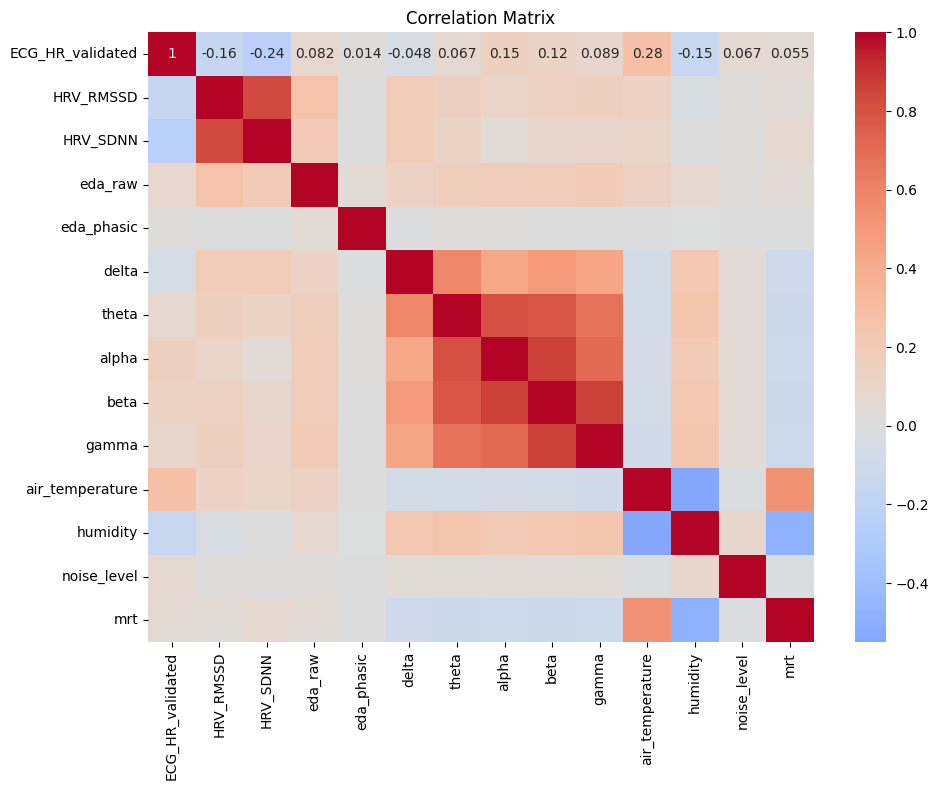



SESSION SUMMARY


,participant_id,session_id,ECG_HR_validated,HRV_RMSSD,HRV_SDNN,eda_raw,theta,alpha,beta,gamma,air_temperature,humidity,noise_level,mrt
0,OE002,Hellerup,94.989460,183.560134,132.978599,1.069652,1.911935,2.798124,0.477413,0.239664,22.811454,78.220722,64.611114,27.552202
1,OE004,Norreport,79.814797,14.627552,39.362897,0.021772,3.620556,2.348963,0.387737,0.131213,22.783585,95.415092,68.491614,25.744406
2,OE005,Hellerup,95.608856,128.010360,100.563567,7.410803,1.891601,2.178804,0.441681,0.253968,30.124890,56.785065,66.962554,39.662764
3,OE005,Nordhavn,93.820881,89.619211,77.420924,6.169707,63.178647,29.486784,5.375865,1.700431,22.558080,92.191510,68.296474,24.006682
4,OE009,Nordhavn,80.321055,73.693551,55.490901,0.006001,2.973372,2.699393,0.415886,0.129548,21.232085,75.775275,67.686996,24.995662
5,OE009,Norrebro,80.564426,22.181851,22.868400,0.018767,3.845161,4.729349,0.737911,0.366442,22.784494,64.955322,67.342629,29.389460
6,OE010,Nordhavn,115.304417,9.505007,29.320260,0.010734,NaN,NaN,NaN,NaN,25.030846,66.778659,67.016188,28.119660
7,OE011,Nordhavn,111.684372,30.133179,42.682510,0.263986,10.491802,9.862179,1.554149,0.447137,27.530088,51.787910,65.248154,39.087580
8,OE015,Norreport,106.205490,20.507574,33.707351,NaN,NaN,NaN,NaN,NaN,22.545707,95.965719,69.606968,24.941546
9,OE018,Hellerup,101.407596,25.089667,39.315125,0.689997,0.910355,0.930503,0.209075,0.073795,30.550668,55.909873,66.827159,35.712290




EXPLORATORY ANALYSIS COMPLETE


In [14]:
full_data_root = "/mnt/raid/emotional_data_raquel/fulldata_mine"

# ======================================================
# LOAD ALL alldata_final.csv FILES
# ======================================================

all_dfs = []

for participant in sorted(os.listdir(full_data_root)):

    participant_path = os.path.join(full_data_root, participant)

    if not os.path.isdir(participant_path):
        continue

    for session in sorted(os.listdir(participant_path)):

        session_path = os.path.join(participant_path, session)

        if not os.path.isdir(session_path):
            continue

        file_path = os.path.join(
            session_path,
            "alldata_final.csv"
        )

        if not os.path.exists(file_path):
            continue

        print(f"Loading → {participant} | {session}")

        try:
            df = pd.read_csv(file_path)

            df["participant"] = participant
            df["session"] = session

            all_dfs.append(df)

        except Exception as e:
            print(f"ERROR: {e}")

# ======================================================
# CONCATENATE
# ======================================================

df_all = pd.concat(all_dfs, ignore_index=True)

print("\n")
print("=" * 80)
print("GLOBAL DATASET")
print("=" * 80)

print(df_all.shape)

# ======================================================
# BASIC OVERVIEW
# ======================================================

print("\n")
print("=" * 80)
print("PARTICIPANTS")
print("=" * 80)

print(df_all["participant"].value_counts())

print("\n")
print("=" * 80)
print("SESSIONS")
print("=" * 80)

print(df_all["session"].value_counts())

# ======================================================
# NUMERIC VARIABLES
# ======================================================

numeric_cols = df_all.select_dtypes(
    include=np.number
).columns.tolist()

print("\n")
print("=" * 80)
print("NUMERIC VARIABLES")
print("=" * 80)

print(numeric_cols)

# ======================================================
# DESCRIPTIVE STATISTICS
# ======================================================

desc_stats = (
    df_all[numeric_cols]
    .describe()
    .T
)

print("\n")
print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

display(desc_stats)

# ======================================================
# SAVE DESCRIPTIVES
# ======================================================

desc_stats.to_csv(
    "/mnt/raid/emotional_data_raquel/descriptive_statistics.csv"
)

# ======================================================
# MISSINGNESS
# ======================================================

missing_df = pd.DataFrame({

    "missing_%": (
        df_all.isna().mean() * 100
    ).sort_values(ascending=False)

})

print("\n")
print("=" * 80)
print("MISSINGNESS")
print("=" * 80)

display(missing_df)

# ======================================================
# MISSINGNESS PLOT
# ======================================================

plt.figure(figsize=(12, 18))

missing_df_sorted = missing_df.sort_values(
    "missing_%",
    ascending=True
)

plt.barh(
    missing_df_sorted.index,
    missing_df_sorted["missing_%"]
)

plt.xlabel("Missing %")
plt.title("Missingness by Variable")

plt.tight_layout()
plt.show()

# ======================================================
# CATEGORY COUNTS
# ======================================================

categorical_cols = [

    "participant_id",
    "session_id",
    "typology",
    "landuse_en",
    "final_label",
    "sex"

]

for col in categorical_cols:

    if col not in df_all.columns:
        continue

    print("\n")
    print("=" * 80)
    print(f"{col.upper()} COUNTS")
    print("=" * 80)

    print(
        df_all[col]
        .value_counts(dropna=False)
    )

# ======================================================
# HISTOGRAMS
# ======================================================

variables_to_plot = [

    "ECG_HR_validated",
    "HRV_RMSSD",
    "HRV_SDNN",

    "eda_raw",
    "eda_phasic",

    "delta",
    "theta",
    "alpha",
    "beta",
    "gamma",

    "air_temperature",
    "humidity",
    "noise_level",
    "mrt"

]

for var in variables_to_plot:

    if var not in df_all.columns:
        continue

    plt.figure(figsize=(6,4))

    df_all[var].hist(
        bins=50
    )

    plt.title(var)

    plt.xlabel(var)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# ======================================================
# BOXPLOTS BY TYPOLOGY
# ======================================================

variables_for_boxplots = [

    "ECG_HR_validated",
    "HRV_RMSSD",
    "HRV_SDNN",

    "eda_raw",

    "theta",
    "alpha",
    "beta",
    "gamma"

]

for var in variables_for_boxplots:

    if var not in df_all.columns:
        continue

    if "typology" not in df_all.columns:
        continue

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df_all,
        x="typology",
        y=var
    )

    plt.title(f"{var} by Typology")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ======================================================
# BOXPLOTS BY LANDUSE
# ======================================================

for var in variables_for_boxplots:

    if var not in df_all.columns:
        continue

    if "landuse_en" not in df_all.columns:
        continue

    plt.figure(figsize=(12,5))

    sns.boxplot(
        data=df_all,
        x="landuse_en",
        y=var
    )

    plt.title(f"{var} by Landuse")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ======================================================
# CORRELATION MATRIX
# ======================================================

corr_vars = [

    "ECG_HR_validated",
    "HRV_RMSSD",
    "HRV_SDNN",

    "eda_raw",
    "eda_phasic",

    "delta",
    "theta",
    "alpha",
    "beta",
    "gamma",

    "air_temperature",
    "humidity",
    "noise_level",
    "mrt"

]

corr_vars = [
    c for c in corr_vars
    if c in df_all.columns
]

corr_df = df_all[corr_vars].corr()

print("\n")
print("=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)

display(corr_df)

# ======================================================
# CORRELATION HEATMAP
# ======================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# ======================================================
# SAVE CORRELATION MATRIX
# ======================================================

# corr_df.to_csv(
#     "/mnt/raid/emotional_data_raquel/correlation_matrix.csv"
# )

# ======================================================
# SESSION LEVEL SUMMARY
# ======================================================

session_summary = (

    df_all
    .groupby(
        ["participant_id", "session_id"]
    )
    .agg({

        "ECG_HR_validated": "mean",

        "HRV_RMSSD": "mean",
        "HRV_SDNN": "mean",

        "eda_raw": "mean",

        "theta": "mean",
        "alpha": "mean",
        "beta": "mean",
        "gamma": "mean",

        "air_temperature": "mean",
        "humidity": "mean",
        "noise_level": "mean",
        "mrt": "mean"

    })
    .reset_index()

)

print("\n")
print("=" * 80)
print("SESSION SUMMARY")
print("=" * 80)

display(session_summary)

# ======================================================
# SAVE SESSION SUMMARY
# ======================================================

# session_summary.to_csv(
#     "/mnt/raid/emotional_data_raquel/session_summary.csv",
#     index=False
# )

# ======================================================
# DONE
# ======================================================

print("\n")
print("=" * 80)
print("EXPLORATORY ANALYSIS COMPLETE")
print("=" * 80)

# Exploratory Analysis Summary

The final exploratory dataset contained:
- 20,184 observations
- 93 variables
- 14 sessions
- 11 participants

Most represented:
- Participant: `OE023`
- Session: `Nordhavn`

---

# Distribution Insights

### ECG insights

`ECG_HR_validated` showed an approximately normal distribution centered around:
- ~80–105 bpm

By typology:
- `N` and `U+N` showed slightly higher HR
- `U+M` and `U+N+M` showed slightly lower HR

By landuse:
- `Urban Center`
- `Public Service Area`
- `Recreational Area`

showed slightly elevated HR values.

---

### EDA insights

`eda_raw` was strongly right-skewed:
- most values close to zero
- sparse high-amplitude peaks

By typology:
- `N` showed the largest EDA peaks
- `U+M` and `U+N+M` showed lower activity

---

### EEG insights

All EEG bands showed right-skewed distributions with strong covariance.

Strongest correlations:
- alpha ↔ beta = 0.90
- theta ↔ alpha = 0.81
- theta ↔ beta = 0.81

By typology:
- `U+M` and `U+N+M` showed higher theta/alpha/beta activity
- `U` showed lower oscillatory power

By landuse:
- `Public Service Area` showed the highest EEG activity
- `Urban Center` showed the lowest

---

# Environmental Insights

### Air temperature

Air temperature showed multiple clusters:
- ~22–24°C
- ~25–26°C
- ~30–31°C

likely reflecting different recording conditions.

### Noise insights

`noise_level` followed a near-normal distribution centered around:
- ~65–70 dB

Noise correlations with physiology were generally weak.

---

# Missingness Insights

Highest missingness:
- `utci`
- `utci_stress_category`
- raw `tk_gps_*` variables

Most complete variables:
- corrected GPS
- gaze coordinates
- climate variables
- landuse variables

Eye-tracking object variables remained highly missing because only some sessions included gaze-object fusion.

---

# Session-Level Insights

Highest average HR:
- `OE022_Nordhavn`
- `OE010_Nordhavn`

Highest EEG activity:
- `OE022_Nordhavn`
- `OE023_Norrebro`

Highest EDA:
- `OE005_Hellerup`

Warmest sessions:
- `OE018_Hellerup`
- `OE019_Hellerup`

---

# Overall Dataset Quality

Overall dataset quality was strong for:
- ECG
- EEG
- climate
- GPS
- landuse
- typology

Main limitations:
- incomplete eye-tracking availability
- missing UTCI variables
- sparse raw `tk_gps_*` signals

___________

________

# Physiological Responses by Urban Typology

The following plots compare standardized physiological responses (`z-scores`) across urban typologies:
- ECG heart rate (`ECG_z`)
- acceleration magnitude
- EDA (`EDA_z`)
- theta (`theta_z`)
- alpha (`alpha_z`)
- beta (`beta_z`)

<Axes: xlabel='typology', ylabel='ECG_z'>

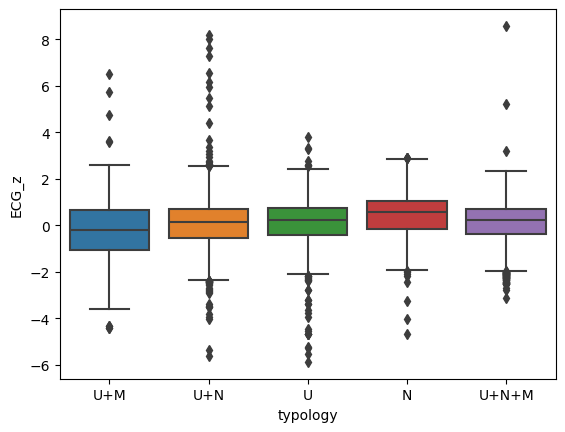

In [9]:
df_all["ECG_z"] = (
    df_all.groupby("participant_id")["ECG_HR_validated"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

sns.boxplot(
    data=df_all,
    x="typology",
    y="ECG_z"
)

<Axes: xlabel='typology', ylabel='acceleration_magnitude'>

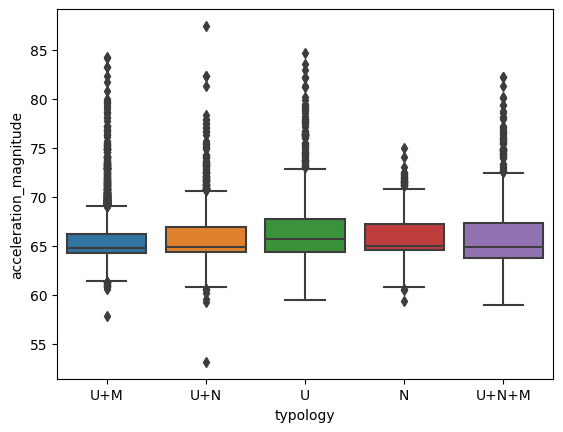

In [10]:
sns.boxplot(
    data=df_all,
    x="typology",
    y="acceleration_magnitude"
)

<Axes: xlabel='typology', ylabel='EDA_z'>

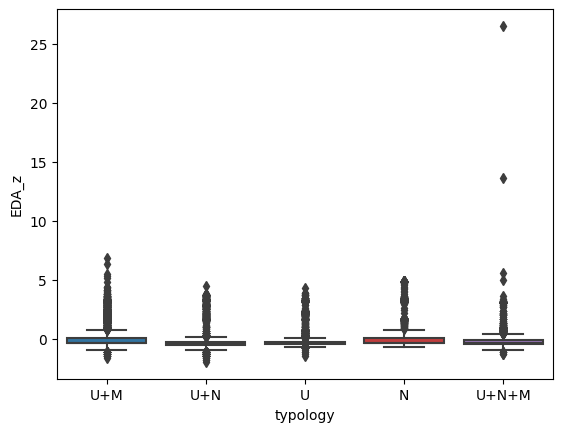

In [11]:
df_all["EDA_log"] = np.log1p(df_all["eda_raw"])

df_all["EDA_z"] = (
    df_all.groupby("participant_id")["EDA_log"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

sns.boxplot(
    data=df_all,
    x="typology",
    y="EDA_z"
)

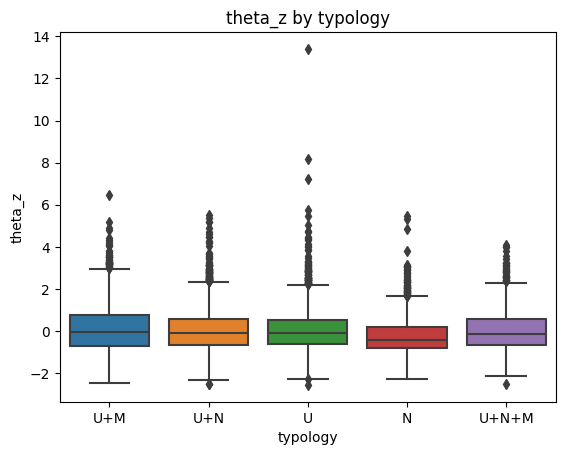

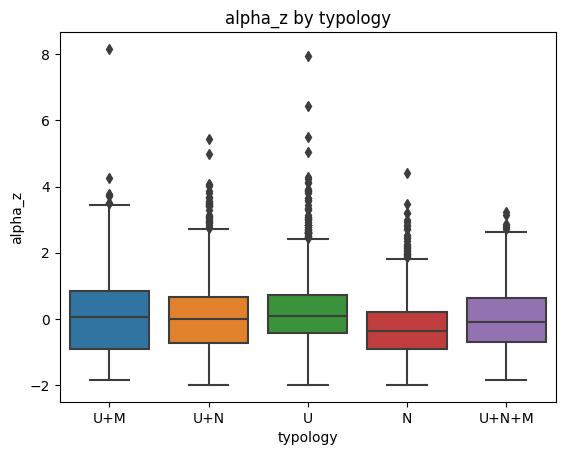

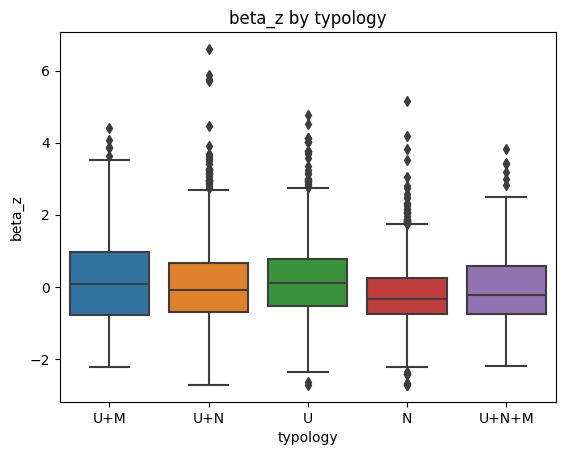

In [12]:
for band in ["theta", "alpha", "beta"]:

    df_all[f"{band}_z"] = (
        df_all.groupby("participant_id")[band]
        .transform(lambda x: (x - x.mean()) / x.std())
    )

    sns.boxplot(
        data=df_all,
        x="typology",
        y=f"{band}_z"
    )

    plt.title(f"{band}_z by typology")
    plt.show()

### ECG insights

After participant-wise z-standardization:
- `N` showed the highest relative ECG activity
- `U+M` showed the lowest relative HR
- `U`, `U+N`, and `U+N+M` remained relatively centered around zero

Differences were visible but modest, with substantial overlap between typologies.

---

### Movement insights

Acceleration magnitude distributions were highly similar across typologies.

Slightly higher movement levels appeared in:
- `U`
- `N`

while:
- `U+M`
showed slightly lower movement overall.

This suggests movement alone is unlikely to explain the physiological differences observed.

---

### EDA insights

EDA showed:
- very compressed central distributions
- large positive outliers

`N` displayed the highest sympathetic activation peaks, while:
- `U+M`
- `U+N`
showed lower overall EDA responses.

`U+N+M` contained several extreme outliers.

---

### EEG insights

Theta:
- `N` showed lower theta z-scores
- `U+M` and `U+N+M` showed relatively higher theta activity

Alpha:
- `N` showed the lowest alpha activity
- `U+M` showed the highest alpha levels

Beta:
- `N` again showed lower beta activity
- `U` and `U+M` showed slightly elevated beta responses

Overall, the EEG patterns suggest:
- greener/mixed typologies (`U+M`) may be associated with relatively higher oscillatory activity
- purely natural (`N`) environments showed lower normalized EEG power despite slightly elevated HR and EDA.